In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv(r"data\olist_customers_dataset.csv")
geolocation = pd.read_csv(r"data\olist_geolocation_dataset.csv")
order_items = pd.read_csv(r"data\olist_order_items_dataset.csv")
order_payments = pd.read_csv(r"data\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(r"data\olist_order_reviews_dataset.csv")
orders = pd.read_csv(r"data\olist_orders_dataset.csv")
products = pd.read_csv(r"data\olist_products_dataset.csv")
sellers = pd.read_csv(r"data\olist_sellers_dataset.csv")
product_category_translation = pd.read_csv(r"data\product_category_name_translation.csv")

### Step 1: Check Data Type

In [3]:
for name, df in {
    "customers" : customers,
    "geolocation" : geolocation,
    "order_items" : order_items,
    "order_payments" : order_payments,
    "order_reviews" : order_reviews,
    "orders" : orders,
    "products" : products,
    "sellers" : sellers,
    "product_category_translation" : product_category_translation
}.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    df.info()


CUSTOMERS
Shape: (99441, 5)
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB

GEOLOCATION
Shape: (1000163, 5)
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city 

### Step 2: Summary Statistics

In [4]:
for name, df in {
    "customers" : customers,
    "geolocation" : geolocation,
    "order_items" : order_items,
    "order_payments" : order_payments,
    "order_reviews" : order_reviews,
    "orders" : orders,
    "products" : products,
    "sellers" : sellers,
    "product_category_translation" : product_category_translation
}.items():
    print(f"\n{name.upper()}")
    print(df.describe().round())


CUSTOMERS
       customer_zip_code_prefix
count                   99441.0
mean                    35137.0
std                     29798.0
min                      1003.0
25%                     11347.0
50%                     24416.0
75%                     58900.0
max                     99990.0

GEOLOCATION
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                    1000163.0        1000163.0        1000163.0
mean                       36574.0            -21.0            -46.0
std                        30549.0              6.0              4.0
min                         1001.0            -37.0           -101.0
25%                        11075.0            -24.0            -49.0
50%                        26530.0            -23.0            -47.0
75%                        63504.0            -20.0            -44.0
max                        99990.0             45.0            121.0

ORDER_ITEMS
       order_item_id     price  freight_value
count   

### Step 3: Check Missing Values

In [6]:
for name, df in {
    "customers" : customers,
    "geolocation" : geolocation,
    "order_items" : order_items,
    "order_payments" : order_payments,
    "order_reviews" : order_reviews,
    "orders" : orders,
    "products" : products,
    "sellers" : sellers,
    "product_category_translation" : product_category_translation
}.items():
    print(f"\n{name.upper()}")
    print(df.isnull().sum())


CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

GEOLOCATION
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

ORDER_ITEMS
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

ORDER_PAYMENTS
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

ORDER_REVIEWS
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

ORDERS
order_id

### Step 4: Check Duplicate Values

In [7]:
for name, df in {
    "customers" : customers,
    "geolocation" : geolocation,
    "order_items" : order_items,
    "order_payments" : order_payments,
    "order_reviews" : order_reviews,
    "orders" : orders,
    "products" : products,
    "sellers" : sellers,
    "product_category_translation" : product_category_translation
}.items():
    print(f"\n{name.upper()}")
    print(df[df.duplicated()])


CUSTOMERS
Empty DataFrame
Columns: [customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state]
Index: []

GEOLOCATION
         geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
15                              1046       -23.546081       -46.644820   
44                              1046       -23.546081       -46.644820   
65                              1046       -23.546081       -46.644820   
66                              1009       -23.546935       -46.636588   
67                              1046       -23.546081       -46.644820   
...                              ...              ...              ...   
1000153                        99970       -28.343273       -51.873734   
1000154                        99950       -28.070493       -52.011342   
1000159                        99900       -27.877125       -52.224882   
1000160                        99950       -28.071855       -52.014716   
1000162                        99950

### Step 5: Check Primary Key Record Duplicates

In [7]:
customers['customer_id'].value_counts()

customer_id
06b8999e2fba1a1fbc88172c00ba8bc7    1
18955e83d337fd6b2def6b18a428ac77    1
4e7b3e00288586ebd08712fdd0374a03    1
b2b6027bc5c5109e529d4dc6358b12c3    1
4f2d8ab171c80ec8364f7c12e35b23ad    1
                                   ..
17ddf5dd5d51696bb3d7c6291687be6f    1
e7b71a9017aa05c9a7fd292d714858e8    1
5e28dfe12db7fb50a4b2f691faecea5e    1
56b18e2166679b8a959d72dd06da27f9    1
274fa6071e5e17fe303b9748641082c8    1
Name: count, Length: 99441, dtype: int64

In [8]:
orders['order_id'].value_counts()

order_id
e481f51cbdc54678b7cc49136f2d6af7    1
53cdb2fc8bc7dce0b6741e2150273451    1
47770eb9100c2d0c44946d9cf07ec65d    1
949d5b44dbf5de918fe9c16f97b45f8a    1
ad21c59c0840e6cb83a9ceb5573f8159    1
                                   ..
9c5dedf39a927c1b2549525ed64a053c    1
63943bddc261676b46f01ca7ac2f7bd8    1
83c1379a015df1e13d02aae0204711ab    1
11c177c8e97725db2631073c19f07b62    1
66dea50a8b16d9b4dee7af250b4be1a5    1
Name: count, Length: 99441, dtype: int64

In [9]:
products['product_id'].value_counts()

product_id
1e9e8ef04dbcff4541ed26657ea517e5    1
3aa071139cb16b67ca9e5dea641aaa2f    1
96bd76ec8810374ed1b65e291975717f    1
cef67bcfe19066a932b7673e239eb23d    1
9dc1a7de274444849c219cff195d0b71    1
                                   ..
a0b7d5a992ccda646f2d34e418fff5a0    1
bf4538d88321d0fd4412a93c974510e6    1
9a7c6041fa9592d9d9ef6cfe62a71f8c    1
83808703fc0706a22e264b9d75f04a2e    1
106392145fca363410d287a815be6de4    1
Name: count, Length: 32951, dtype: int64

In [10]:
sellers['seller_id'].value_counts()

seller_id
3442f8959a84dea7ee197c632cb2df15    1
d1b65fc7debc3361ea86b5f14c68d2e2    1
ce3ad9de960102d0677a81f5d0bb7b2d    1
c0f3eea2e14555b6faeea3dd58c1b1c3    1
51a04a8a6bdcb23deccc82b0b80742cf    1
                                   ..
98dddbc4601dd4443ca174359b237166    1
f8201cab383e484733266d1906e2fdfa    1
74871d19219c7d518d0090283e03c137    1
e603cf3fec55f8697c9059638d6c8eb5    1
9e25199f6ef7e7c347120ff175652c3b    1
Name: count, Length: 3095, dtype: int64

### Step 6: Check Categorical Data

In [8]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "product_category_translation": product_category_translation
}
for dataset_name, df in datasets.items():
    print(f"\nDATASET: {dataset_name}")
    print('-'*30)

    for col in df.columns:
        if df[col].dtype == 'str' and df[col].nunique() >= 2:
            print(df[col].value_counts())
            print('-'*50)


DATASET: customers
------------------------------
customer_id
06b8999e2fba1a1fbc88172c00ba8bc7    1
18955e83d337fd6b2def6b18a428ac77    1
4e7b3e00288586ebd08712fdd0374a03    1
b2b6027bc5c5109e529d4dc6358b12c3    1
4f2d8ab171c80ec8364f7c12e35b23ad    1
                                   ..
17ddf5dd5d51696bb3d7c6291687be6f    1
e7b71a9017aa05c9a7fd292d714858e8    1
5e28dfe12db7fb50a4b2f691faecea5e    1
56b18e2166679b8a959d72dd06da27f9    1
274fa6071e5e17fe303b9748641082c8    1
Name: count, Length: 99441, dtype: int64
--------------------------------------------------
customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
1a29b476fee25c95fbafc67c5ac95cf8     1
d52a67c98be1cf6a5c84435bd38d095d     1
e9f50caf99f032f0bf3c55141f019d99     1
73c2643a0a458b49f58cea58833b192e     1
84732c5050c01db9b2

## Data Cleaning

### Handling Missing Data

In [5]:
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].fillna('No Title')
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].fillna('No Comment')

In [6]:
products['product_category_name'] = products['product_category_name'].fillna('Unknown')
products['product_name_lenght'] = products['product_name_lenght'].fillna(0)
products['product_description_lenght'] = products['product_description_lenght'].fillna(0)
products['product_photos_qty'] = products['product_photos_qty'].fillna(0)
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g']).median()
products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm']).median()
products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm']).median()
products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm']).median()


In [11]:
orders[orders['order_approved_at'].isna()]['order_status'].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [15]:
orders[(orders['order_approved_at'].isna()) & (orders['order_status'] == 'delivered')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaN,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16 00:00:00
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaN,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20 00:00:00


### Fixing Inconsistent Formating

In [7]:
customers['customer_city'].unique()
customers['customer_city'] = customers['customer_city'].str.lower().str.strip()

customers['customer_state'].unique()
customers['customer_state'] = customers['customer_state'].str.upper().str.strip()

In [8]:
geolocation['geolocation_city'].unique()

from unidecode import unidecode

geolocation['geolocation_city'] = geolocation['geolocation_city'].astype('string').str.lower().str.strip().apply(unidecode).str.replace(r'\s+','',regex = True).str.replace(r'[^a-z0-9\s]','',regex = True).str.replace({'sp':'saopaulo'})

geolocation['geolocation_state'].unique()

geolocation['geolocation_state'] = geolocation['geolocation_state'].str.upper().str.strip()

In [9]:
products['product_category_name'].unique()
products['product_category_name'] = products['product_category_name'].replace({'casa_conforto_2' : 'casa_conforto'})

products['product_category_name'] = products['product_category_name'].replace({'eletrodomesticos_2' : 'eletrodomesticos'})

In [13]:
products['product_category_name'].unique()

<ArrowStringArray>
[                                    'perfumaria',
                                          'artes',
                                  'esporte_lazer',
                                          'bebes',
                          'utilidades_domesticas',
                          'instrumentos_musicais',
                                     'cool_stuff',
                               'moveis_decoracao',
                               'eletrodomesticos',
                                     'brinquedos',
                                'cama_mesa_banho',
               'construcao_ferramentas_seguranca',
                         'informatica_acessorios',
                                   'beleza_saude',
                               'malas_acessorios',
                             'ferramentas_jardim',
                              'moveis_escritorio',
                                     'automotivo',
                                    'eletronicos',
            

In [10]:
sellers['seller_city'].unique()

sellers['seller_city'] = sellers['seller_city'].replace({
      4482255 : 'rio de janeiro',
     'angra dos reis rj' : 'angra dos reis',
     'auriflama/sp' : 'auriflama',
     'balenario camboriu' : 'balneario camboriu',
     'barbacena/ minas gerais' : 'barbacena',
     'belo horizont' : 'belo horizonte',
     'brasilia df' : 'brasilia',
     'carapicuiba / sao paulo' : 'carapicuiba',
     'cariacica / es' : 'cariacica',
     'cascavael' : 'cascavel',
     'ferraz de  vasconcelos' : 'ferraz de vasconcelos',
     'jacarei / sao paulo' : 'jacarei',
     'lages - sc' : 'lages',
     'maua/sao paulo' : 'maua',
     'mogi das cruses' : 'mogi das cruzes', 'mogi das cruzes / sp' : 'mogi das cruzes',
     'novo hamburgo, rio grande do sul, brasil' : 'novo hamburgo',
     'pinhais/pr' : 'pinhais',
     'ribeirao preto / sao paulo' : 'ribeirao preto', 'riberao preto' : 'ribeirao preto', 'ribeirao pretp' : 'ribeirao preto',
     'rio de janeiro \rio de janeiro' : 'rio de janeiro', 'rio de janeiro / rio de janeiro' : 'rio de janeiro', 'rio de janeiro, rio de janeiro, brasil' : 'rio de janeiro',
     "santa barbara dÂ´oeste" : "santa barbara d'oeste", "santa barbara d oeste" : "santa barbara d'oeste",
     'santo andre/sao paulo' : 'santo andre',
     'sao  jose dos pinhais' : 'sao jose dos pinhais',
     'sao  paulo' : 'sao paulo',
     'sao bernardo do capo' : 'sao bernardo do campo',
     'sao jose do rio pret' : 'sao jose do rio preto',
     'sao jose dos pinhas' : 'sao jose dos pinhais',
     "sao miguel d'oeste" : 'sao miguel do oeste',
     'sao paulo / sao paulo' : 'sao paulo', 'sao pauo' : 'sao paulo', 'sao paulo - sp' : 'sao paulo', 'sao paulo sp' : 'sao paulo', 'sao paluo' : 'sao paulo', 'sao paulop' : 'sao paulo',
     'sao sebastiao da grama/sp' : 'sao sebastiao da grama', 'sbc/sp' : 'sbc',
     'sp / sp' : 'sp',
     'tabao da serra' : 'taboao da serra',
     'vendas@creditparts.com.br' : 'vendas'
     })

In [15]:
sellers['seller_state'].unique()

sellers.groupby('seller_city')['seller_state'].unique().loc[
    lambda x: x.apply(len) > 1
]
#sellers.groupby('seller_city')['seller_state'].nunique().sort_values(ascending=False)

seller_city
andradas                       [SP, MG]
belo horizonte                 [MG, SP]
blumenau                       [SC, SP]
caxias do sul                  [SP, RS]
chapeco                        [SC, SP]
curitiba                       [PR, SP]
florianopolis                  [SC, SP]
guaira                         [PR, SP]
ipira                          [BA, SP]
itajai                         [SC, SP]
jacutinga                      [RS, MG]
juiz de fora                   [MG, SP]
londrina                       [PR, SP]
marechal candido rondon    [SP, PR, PA]
palhoca                        [SC, SP]
pinhais                        [PR, SP]
pinhalzinho                    [SC, SP]
porto alegre                   [RS, SP]
rio bonito                     [RJ, SP]
rio de janeiro             [RJ, RN, SP]
sao jose dos pinhais           [PR, SP]
vila velha                     [SP, ES]
volta redonda                  [SP, RJ]
Name: seller_state, dtype: object

In [11]:
state_mapping = {
    'andradas' : 'MG',
    'belo horizonte' : 'MG',
    'blumenau' : 'SC',
    'caxias do sul' : 'RS',
    'chapeco' : 'SC',
    'curitiba' : 'PR',
    'florianopolis' : 'SC',
    'guaira' : 'PR',
    'ipira' : 'BA',
    'itajai' : 'SC',
    'jacutinga' : 'MG',
    'juiz de fora' : 'MG',
    'londrina' : 'PR',
    'marechal candido rondon' : 'PR',
    'palhoca' : 'SC',
    'pinhais' : 'PR',
    'pinhalzinho' : 'SP',
    'porto alegre' : 'RS',
    'rio bonito' : 'RJ',
    'rio de janeiro' : 'RJ',
    'sao jose dos pinhais' : 'PR',
    'vila velha' : 'ES',
    'volta redonda' : 'RJ'
    }

sellers['seller_state'] = sellers['seller_city'].map(state_mapping).fillna(sellers['seller_state'])

### Handling Duplicates

In [17]:
geolocation[geolocation.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,saopaulo,SP
44,1046,-23.546081,-46.644820,saopaulo,SP
65,1046,-23.546081,-46.644820,saopaulo,SP
66,1009,-23.546935,-46.636588,saopaulo,SP
67,1046,-23.546081,-46.644820,saopaulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getuliovargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [12]:
geolocation.drop_duplicates(inplace=True)

In [13]:
customers['customer_id'].duplicated().sum()
customers['customer_unique_id'].duplicated().sum()

orders['order_id'].duplicated().sum()

order_reviews['review_id'].duplicated().sum()

order_reviews['review_id'].duplicated().sum()

products['product_id'].duplicated().sum()

sellers['seller_id'].duplicated().sum()

np.int64(0)

In [17]:
order_reviews[ order_reviews['review_id'].duplicated(keep=False)].sort_values('review_id')

#order_reviews.groupby('review_id')['order_id'].nunique().sort_values(ascending=False).head(50)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,No Title,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,No Title,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,No Title,No Comment,2017-09-21 00:00:00,2017-09-26 03:27:47
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,No Title,No Comment,2017-09-21 00:00:00,2017-09-26 03:27:47
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,No Title,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
...,...,...,...,...,...,...,...
40378,fe5c833752953fed3209646f1f63b53c,d3775e436e60258e62e678a0f68a0f8d,1,No Title,"Comprei dois produtos e ambos, mesmo enviados ...",2018-02-28 00:00:00,2018-02-28 13:57:52
7870,ff2fc9e68f8aabfbe18d710b83aabd30,2da58e0a7dcfa4ce1e00fad9d03ca3b5,2,No Title,No Comment,2018-03-17 00:00:00,2018-03-19 11:44:15
82521,ff2fc9e68f8aabfbe18d710b83aabd30,1078d496cc6ab9a8e6f2be77abf5091b,2,No Title,No Comment,2018-03-17 00:00:00,2018-03-19 11:44:15
1985,ffb8cff872a625632ac983eb1f88843c,c88b1d1b157a9999ce368f218a407141,3,No Title,No Comment,2017-07-22 00:00:00,2017-07-26 13:41:07


### Correcting Data Types

In [15]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [16]:
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

In [17]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [18]:
products['product_photos_qty'] = products['product_photos_qty'].astype(int)

### Handling Outliers

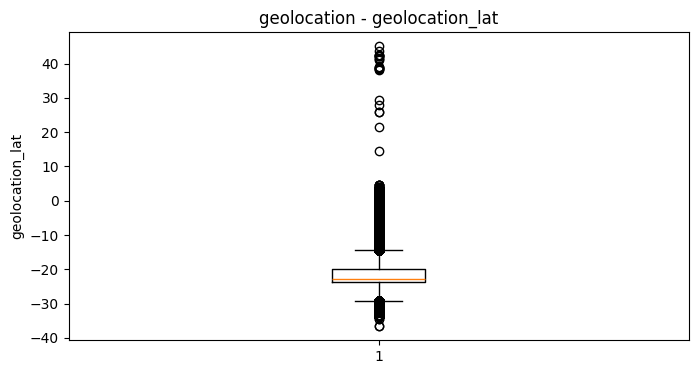

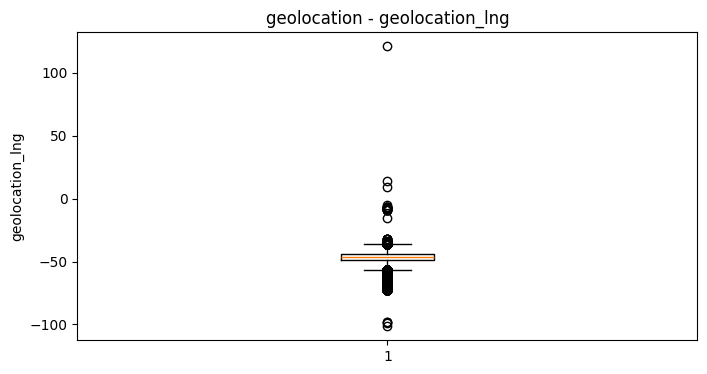

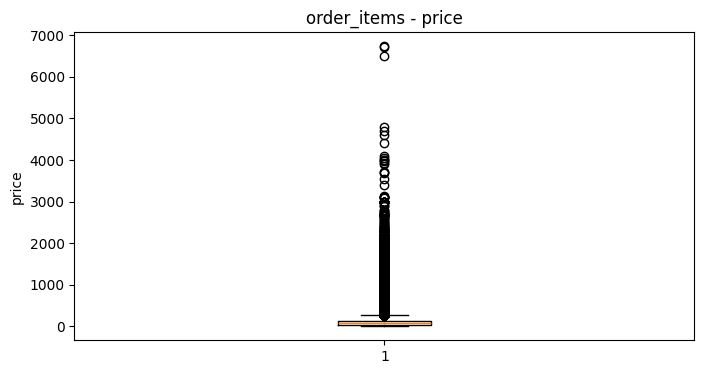

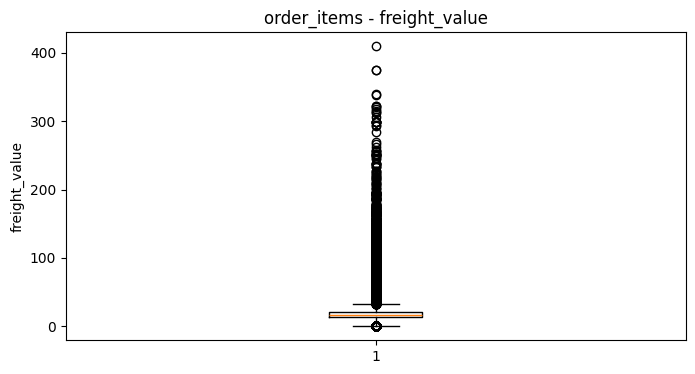

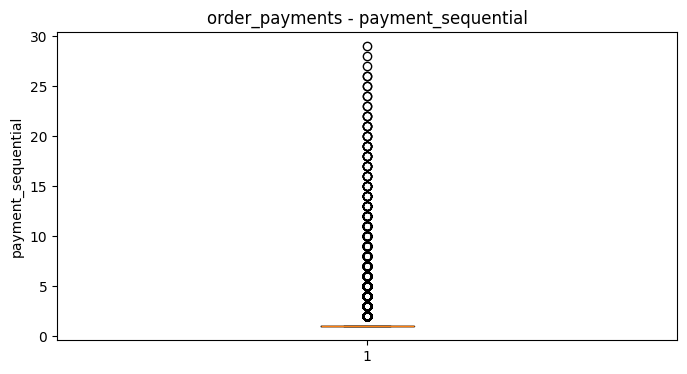

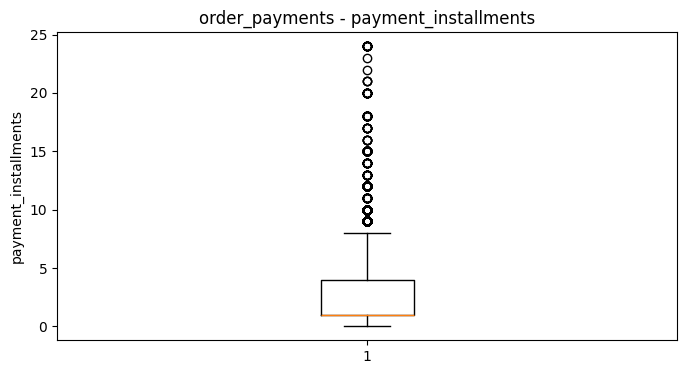

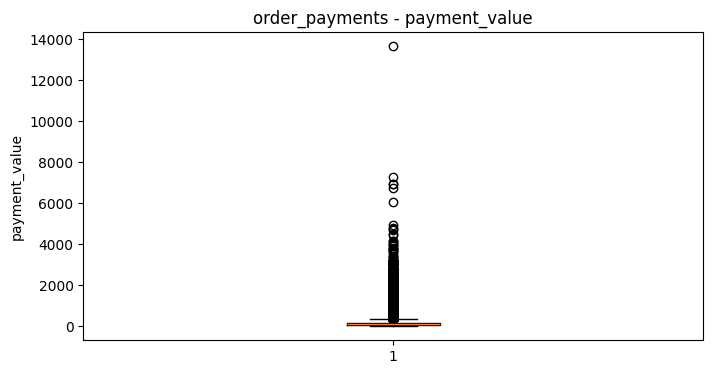

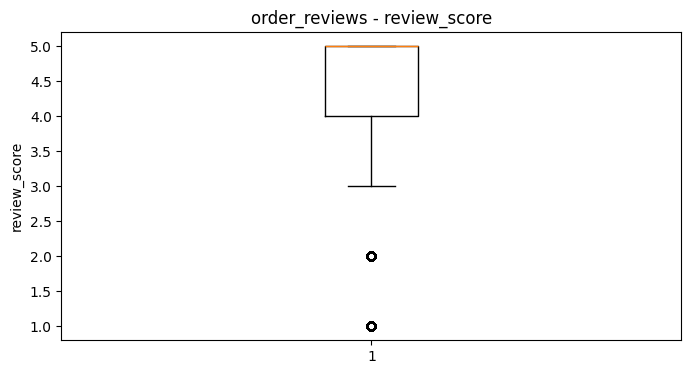

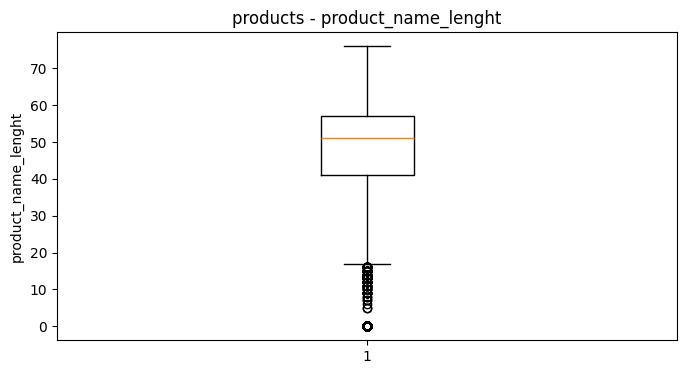

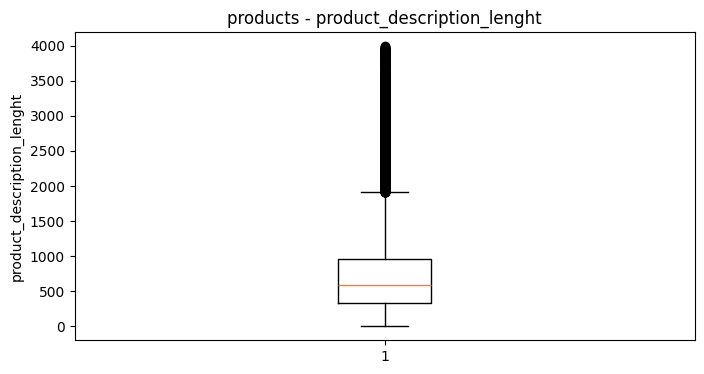

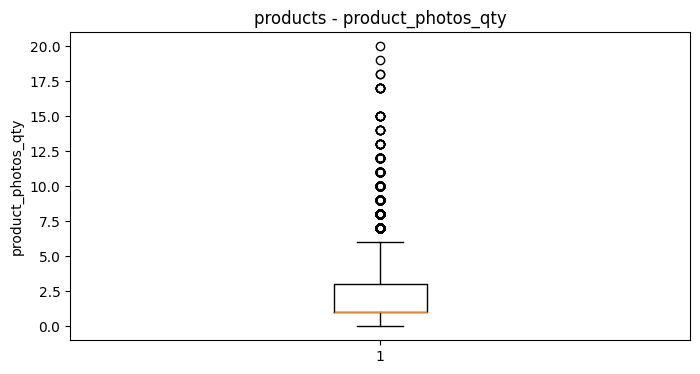

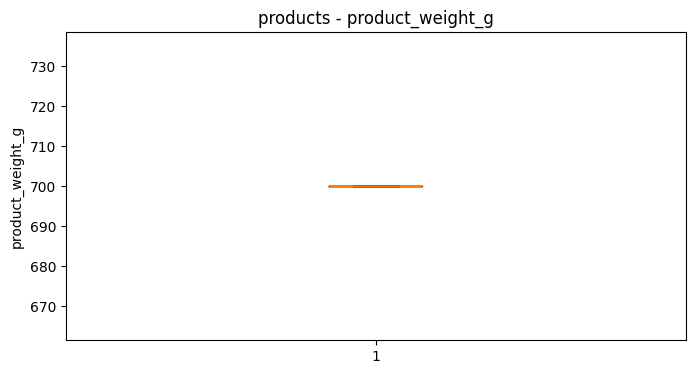

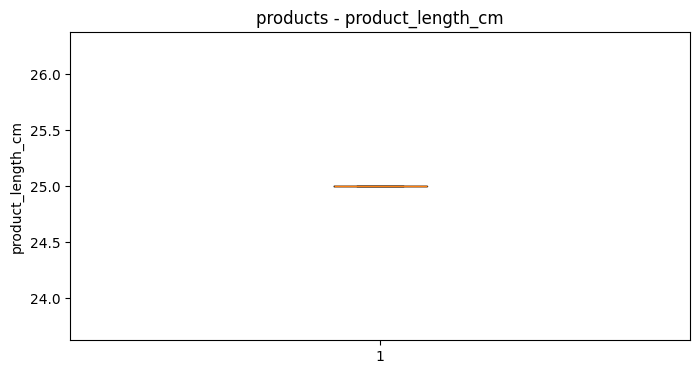

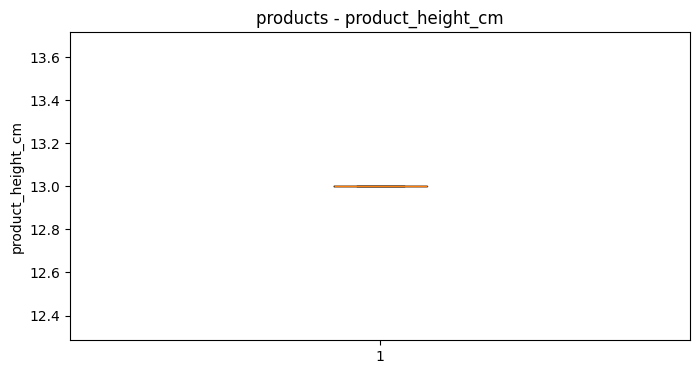

In [24]:
datasets = {
    "customers" : customers,
    "geolocation" : geolocation,
    "order_items" : order_items,
    "order_payments" : order_payments,
    "order_reviews" : order_reviews,
    "orders" : orders,
    "products" : products,
    "sellers" : sellers
}
for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        if 'id' in col.lower() or 'zip' in col.lower():
            continue

        plt.figure(figsize=(8,4))
        plt.boxplot(df[col].dropna())
        plt.title(f'{name} - {col}')
        plt.ylabel(col)
        plt.show()

In [25]:
numeric_cols = products.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = products[col].quantile(0.25)
    Q3 = products[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = products[(products[col] < lower) | (products[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

product_name_lenght: 740 outliers
product_description_lenght: 2096 outliers
product_photos_qty: 849 outliers
product_weight_g: 0 outliers
product_length_cm: 0 outliers
product_height_cm: 0 outliers
product_width_cm: 0 outliers


In [26]:
numeric_cols = order_items.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = order_items[col].quantile(0.25)
    Q3 = order_items[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = order_items[(order_items[col] < lower) | (order_items[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

order_item_id: 13984 outliers
price: 8427 outliers
freight_value: 12134 outliers


In [27]:
order_items['price'].describe()
order_items['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [28]:
numeric_cols = order_payments.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = order_payments[col].quantile(0.25)
    Q3 = order_payments[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = order_payments[(order_payments[col] < lower) | (order_payments[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

payment_sequential: 4526 outliers
payment_installments: 6313 outliers
payment_value: 7981 outliers


In [29]:
order_payments['payment_sequential'].describe()

count    103886.000000
mean          1.092679
std           0.706584
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          29.000000
Name: payment_sequential, dtype: float64

In [21]:
datasets = {
    "customers" : customers,
    "geolocation" : geolocation,
    "order_items" : order_items,
    "order_payments" : order_payments,
    "order_reviews" : order_reviews,
    "orders" : orders,
    "products" : products,
    "sellers" : sellers
}

for name, df in datasets.items():
    df.to_csv(f"E:\Brazilian E-Commerce Public Dataset by Olist\Cleaned_Data\{name}_Cleaned.csv", index = False)

<string>:13: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:13: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:13: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
<string>:13: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:13: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:13: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_30508\2978655

### Univariate Analysis

#### Numerical Columns

In [31]:
datsets = {
    "customers" : customers,
        "geolocation" : geolocation,
        "order_items" : order_items,
        "order_payments" : order_payments,
        "order_reviews" : order_reviews,
        "orders" : orders,
        "products" : products,
        "sellers" : sellers
}
for name, df in datsets.items():
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        if 'id' in col.lower() or 'zip' in col.lower():
            continue
        summary = df[[col]].describe().T
        summary['median'] = df[col].median()
        summary['IQR'] = summary['75%'] - summary['25%']
        summary['skewness'] = df[col].skew()
        print(f"\n{name} - {col}")
        display(summary)


geolocation - geolocation_lat


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
geolocation_lat,720384.0,-20.974123,5.918654,-36.605374,-23.601844,-22.861656,-19.915985,45.065933,-22.861656,3.685859,1.462522



geolocation - geolocation_lng


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
geolocation_lng,720384.0,-46.452191,4.419949,-101.466766,-48.911774,-46.645782,-43.786601,121.105394,-46.645782,5.125173,-0.0469



order_items - price


...

,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
product_weight_g,32951.0,700.0,0.0,700.0,700.0,700.0,700.0,700.0,700.0,0.0,0.0



products - product_length_cm


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
product_length_cm,32951.0,25.0,0.0,25.0,25.0,25.0,25.0,25.0,25.0,0.0,0.0



products - product_height_cm


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
product_height_cm,32951.0,13.0,0.0,13.0,13.0,13.0,13.0,13.0,13.0,0.0,0.0


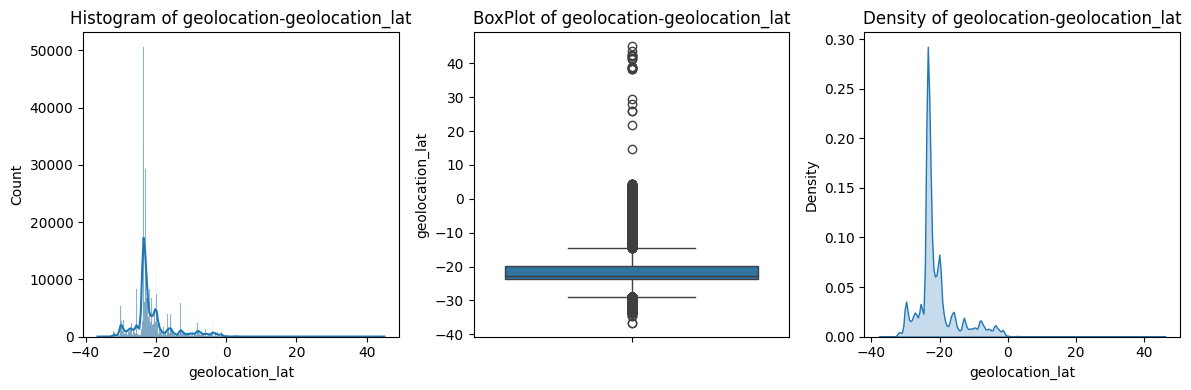

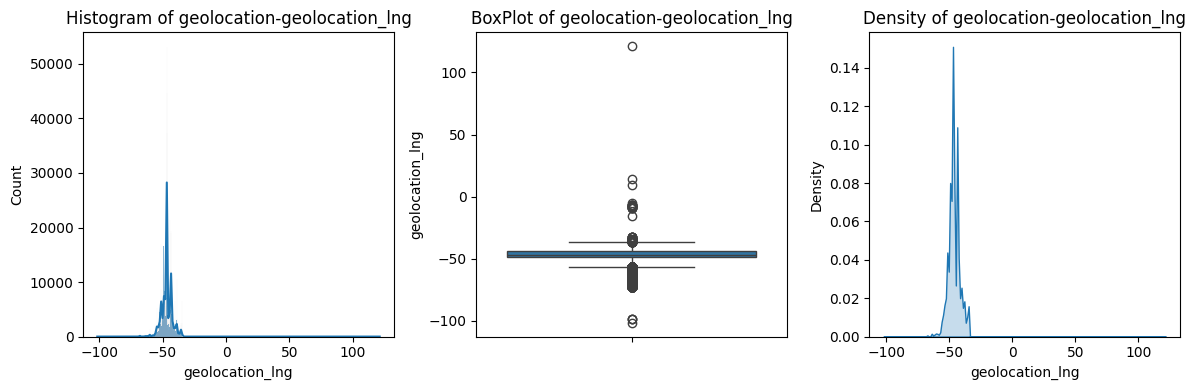

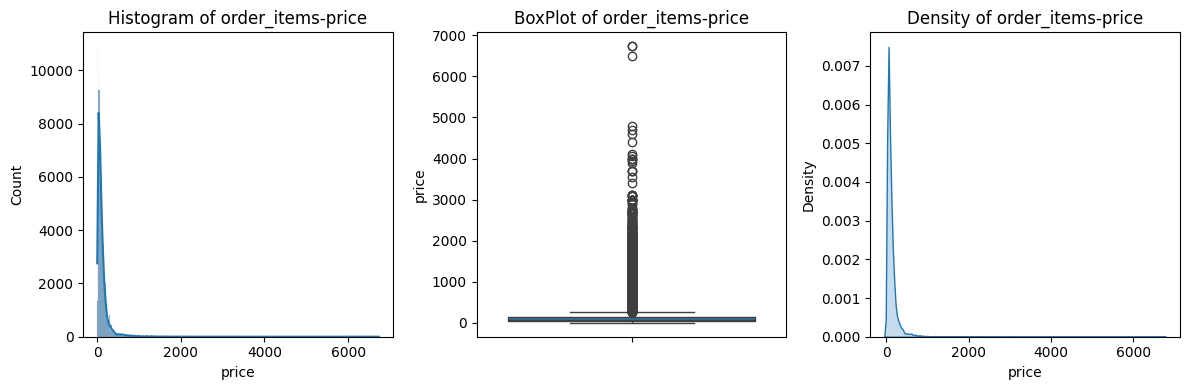

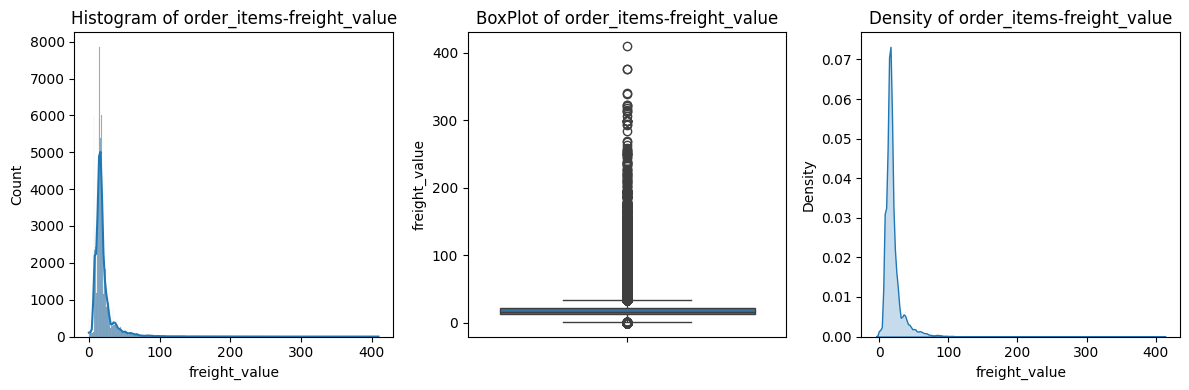

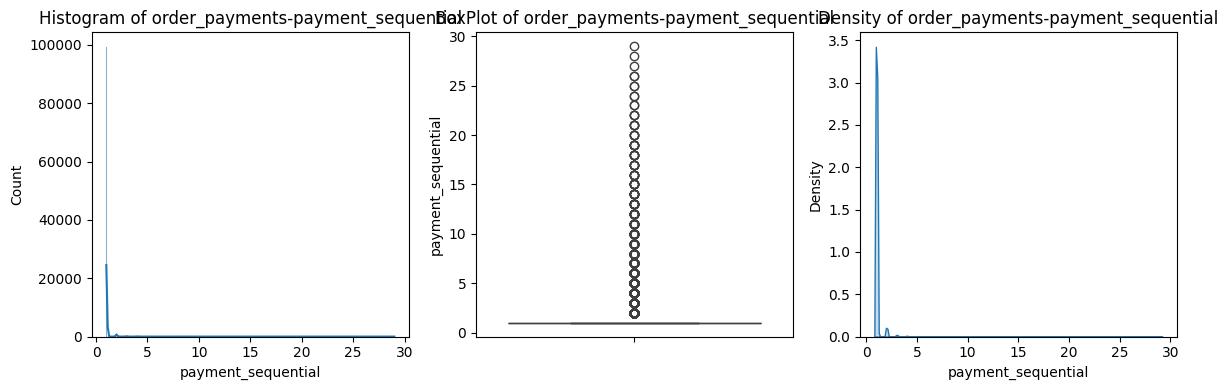

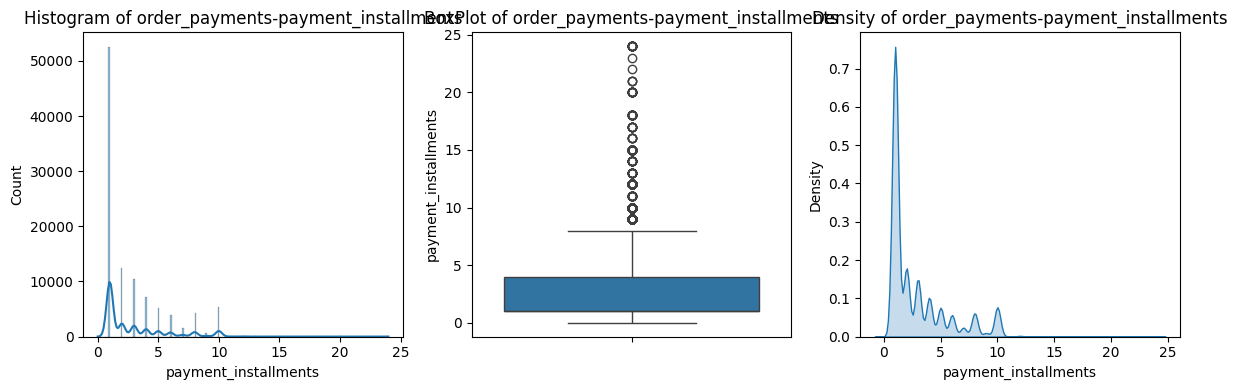

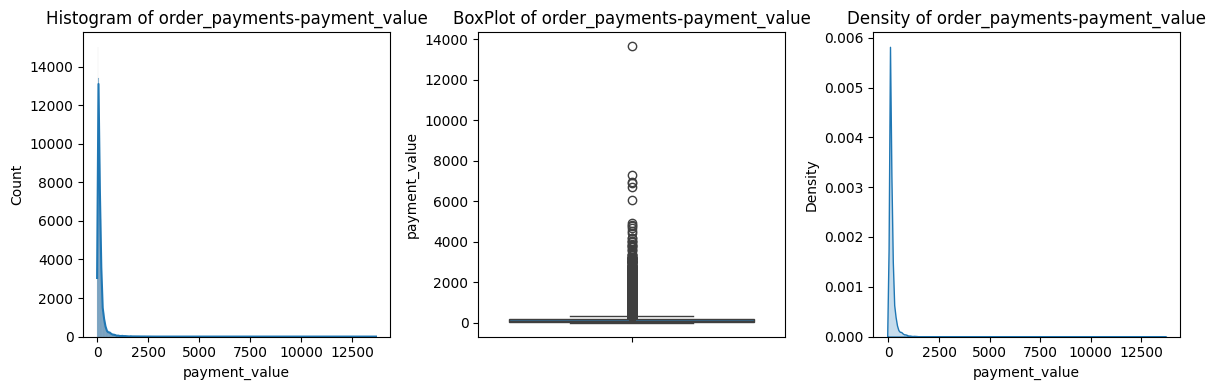

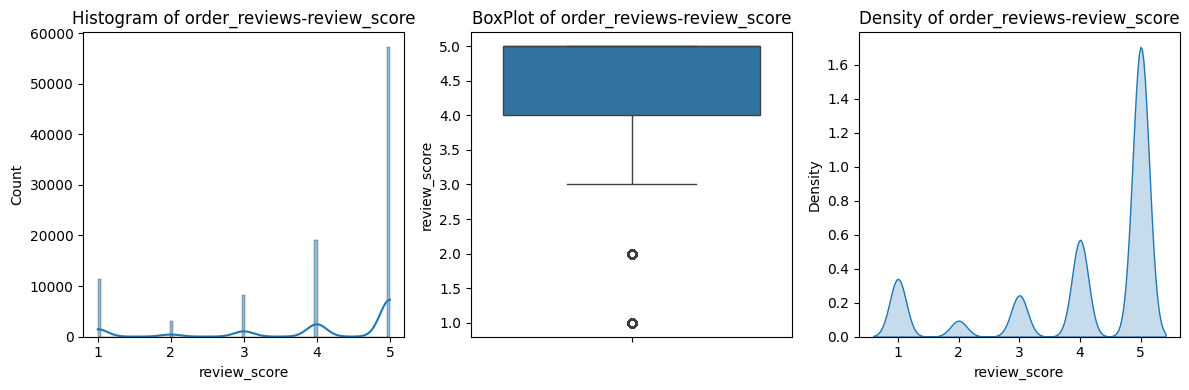

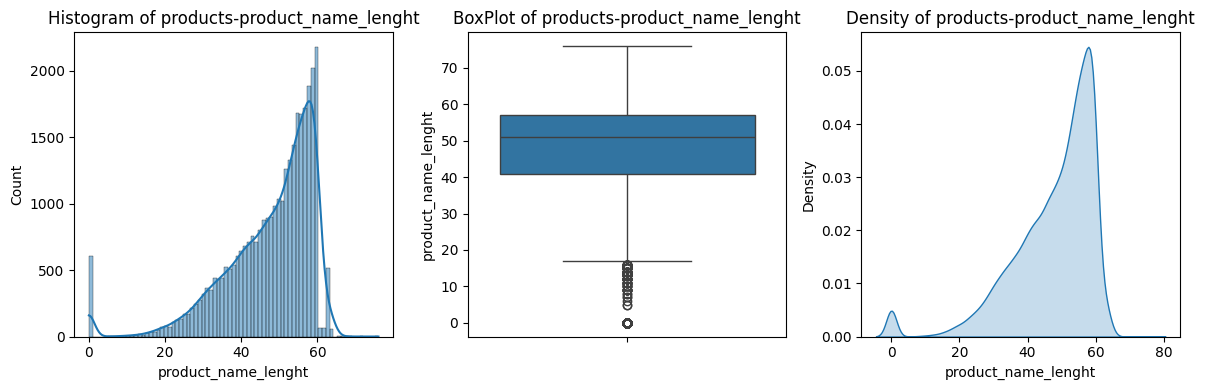

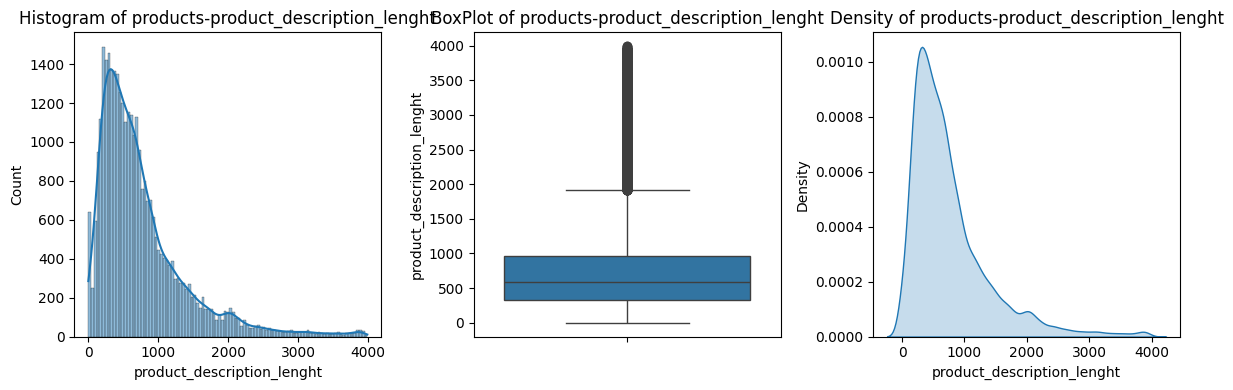

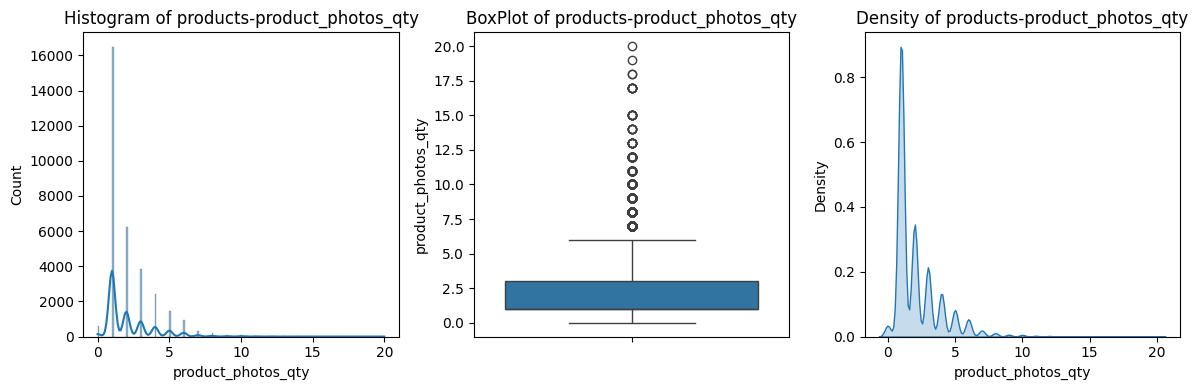

C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_4000\3665354340.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True)


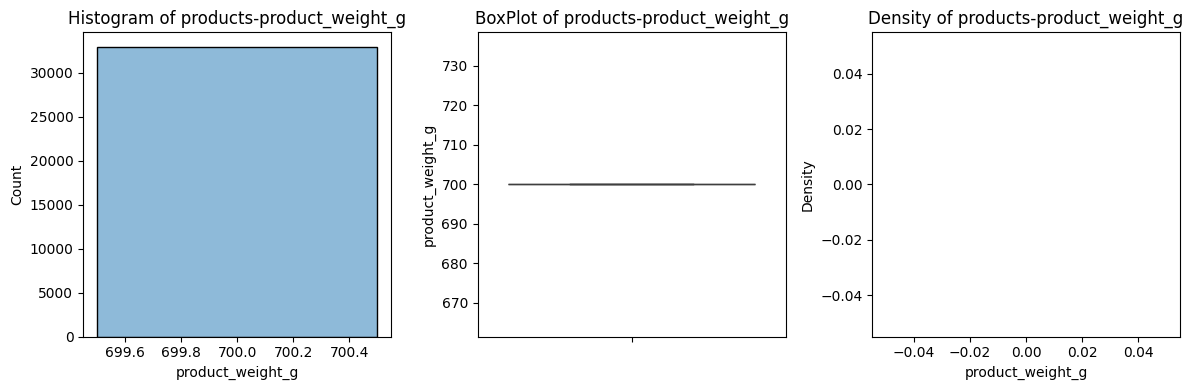

C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_4000\3665354340.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True)


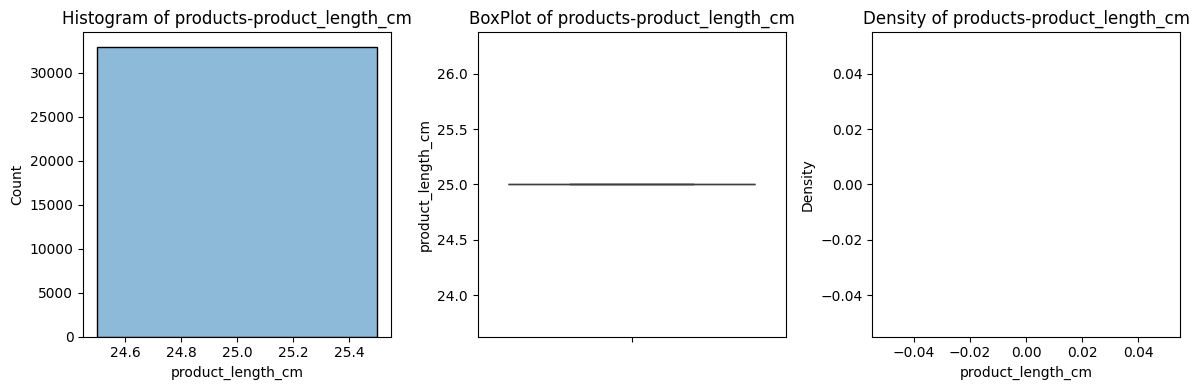

C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_4000\3665354340.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True)


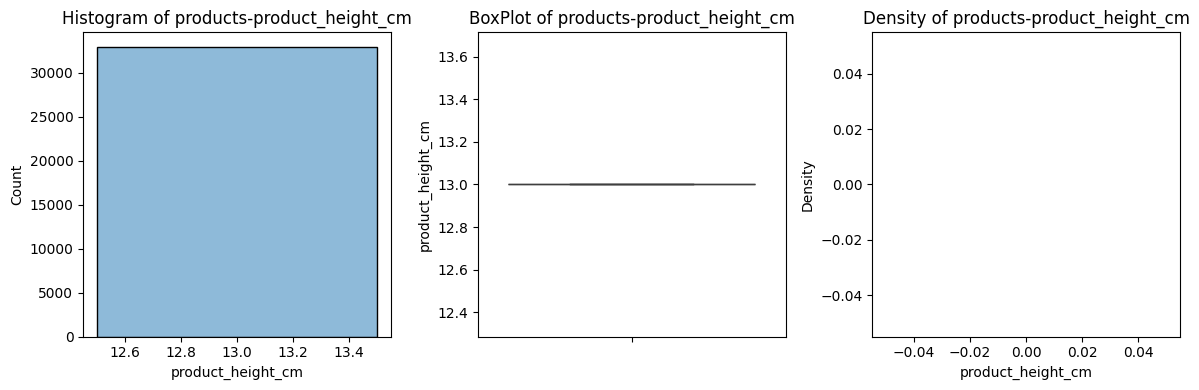

In [32]:
datsets = {
    "customers" : customers,
        "geolocation" : geolocation,
        "order_items" : order_items,
        "order_payments" : order_payments,
        "order_reviews" : order_reviews,
        "orders" : orders,
        "products" : products,
        "sellers" : sellers
}
for name, df in datsets.items():
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        if 'id' in col.lower() or 'zip' in col.lower():
            continue
        plt.figure(figsize = (12, 4))

        plt.subplot(1, 3, 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Histogram of {name}-{col}')

        plt.subplot(1, 3, 2)
        sns.boxplot(df[col], fill=True)
        plt.title(f'BoxPlot of {name}-{col}')

        plt.subplot(1, 3, 3)
        sns.kdeplot(df[col], fill=True)
        plt.title(f'Density of {name}-{col}')

        plt.tight_layout()
        plt.show()


#### Categorical Columns


Frequency Count for customers-customer_city:
 customer_city
sao paulo              15540
rio de janeiro          6882
belo horizonte          2773
brasilia                2131
curitiba                1521
                       ...  
siriji                     1
natividade da serra        1
monte bonito               1
sao rafael                 1
eugenio de castro          1
Name: count, Length: 4119, dtype: int64


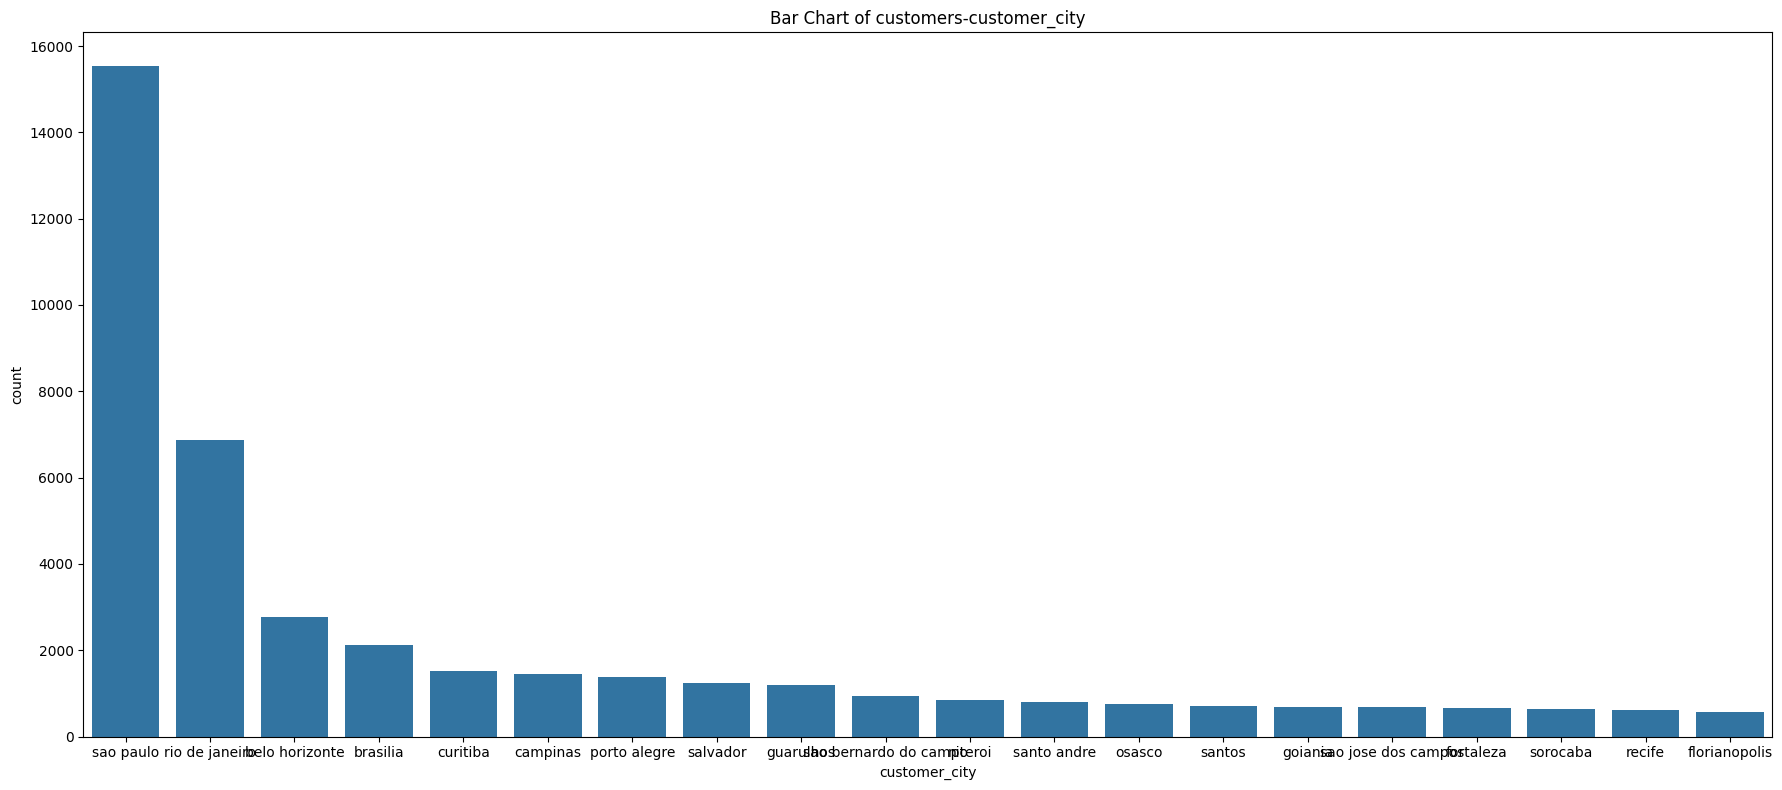


Frequency Count for customers-customer_state:
 customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64


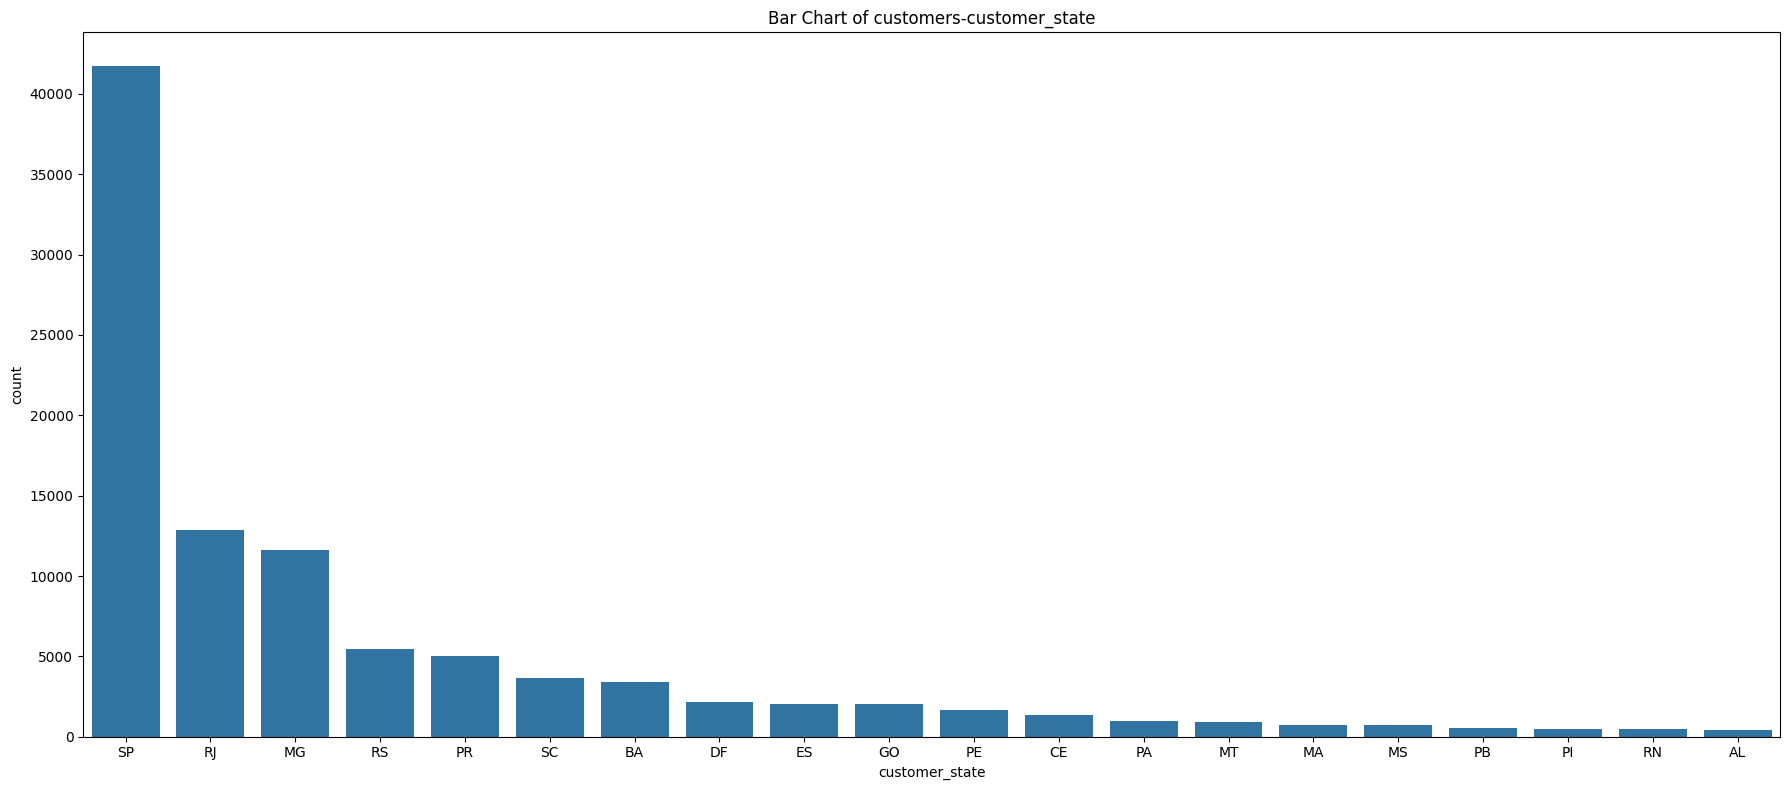


Frequency Count for geolocation-geolocation_city:
 geolocation_city
saopaulo               91796
riodejaneiro           35177
belohorizonte          19474
curitiba               11263
portoalegre             8702
                       ...  
santamargaridadosul        1
rolador                    1
setedesetembro             1
lajeadodobugre             1
padregonzales              1
Name: count, Length: 5899, dtype: int64


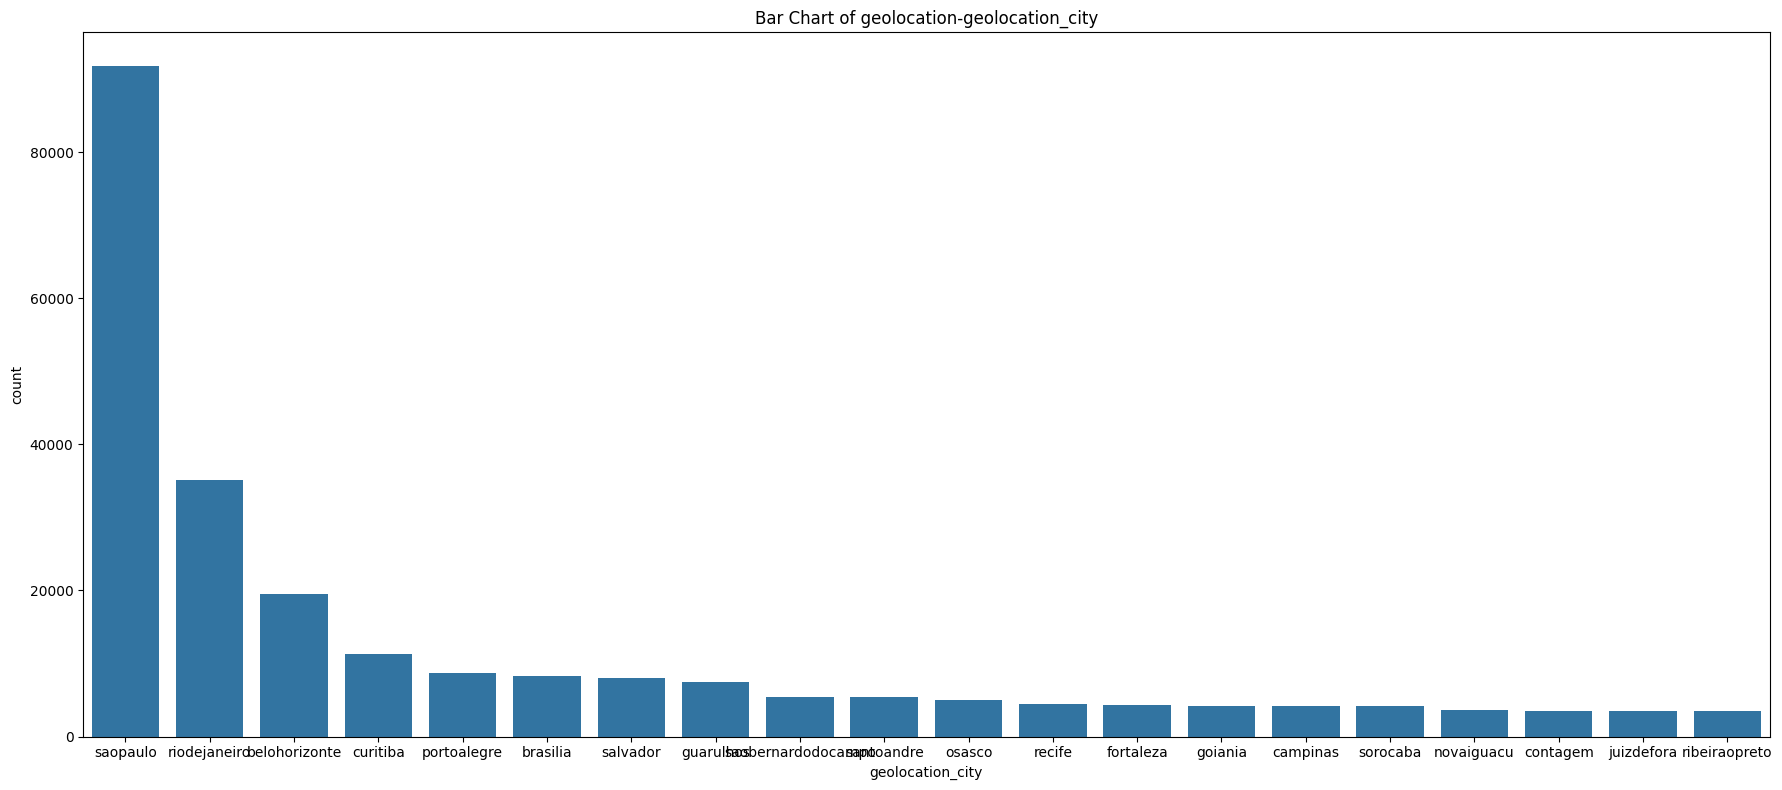


Frequency Count for geolocation-geolocation_state:
 geolocation_state
SP    274626
MG    100542
RJ     77655
RS     47654
PR     44505
SC     29371
BA     27440
GO     15057
PE     13096
ES     12363
CE      9506
MT      9113
DF      8516
MS      8502
PA      8338
MA      6155
PB      4709
RN      3975
PI      3540
AL      3326
TO      2956
SE      2644
RO      2487
AM      1977
AC      1034
AP       729
RR       568
Name: count, dtype: int64


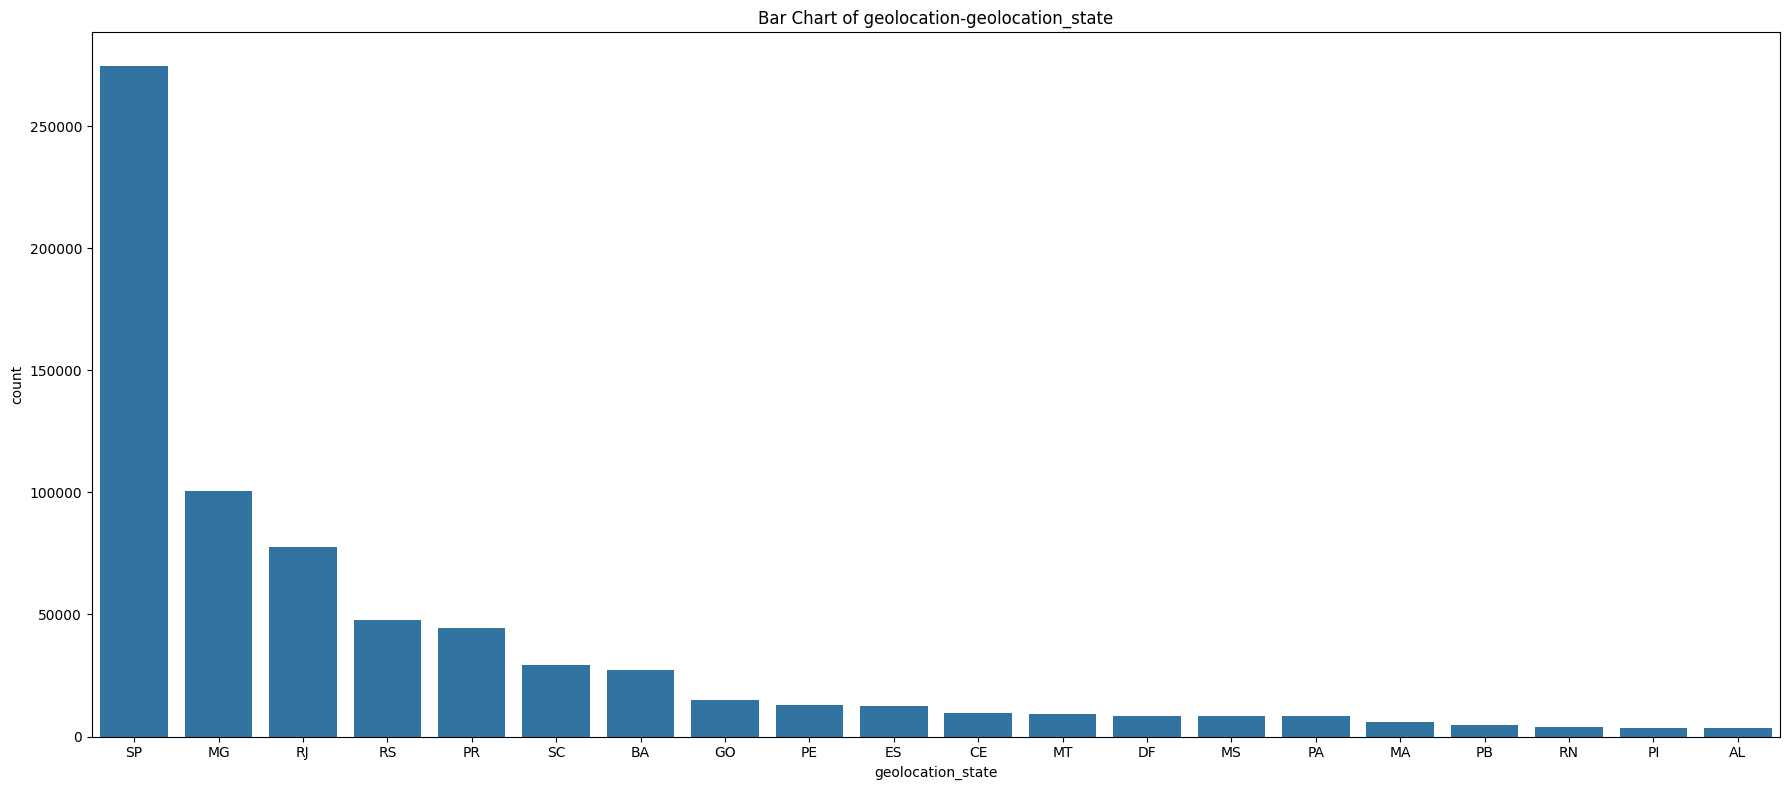


Frequency Count for order_payments-payment_type:
 payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


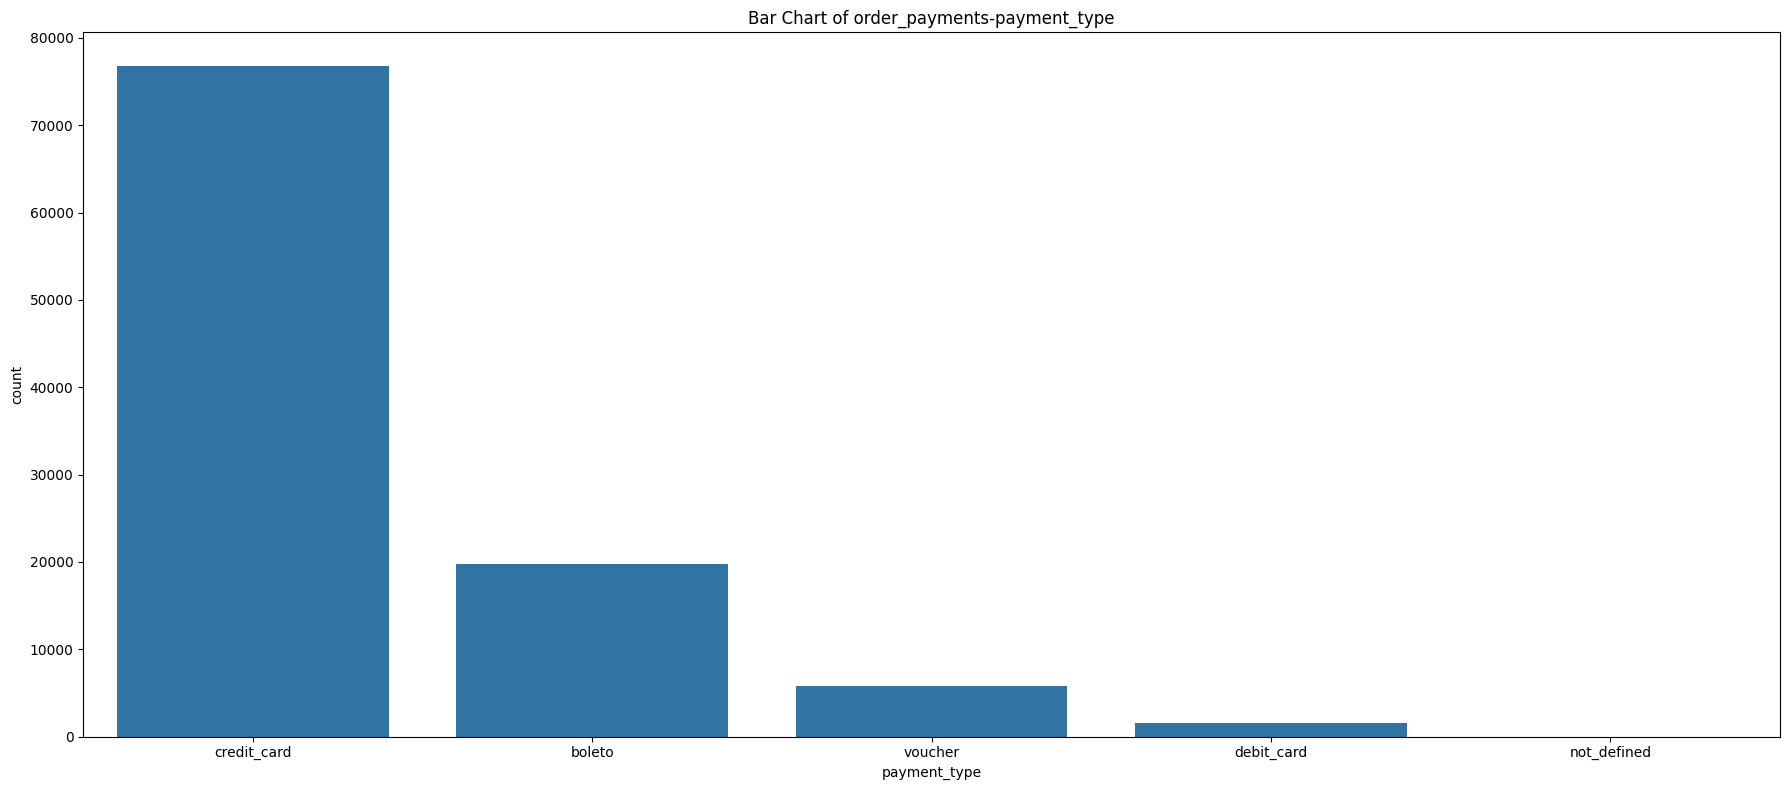


Frequency Count for orders-order_status:
 order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


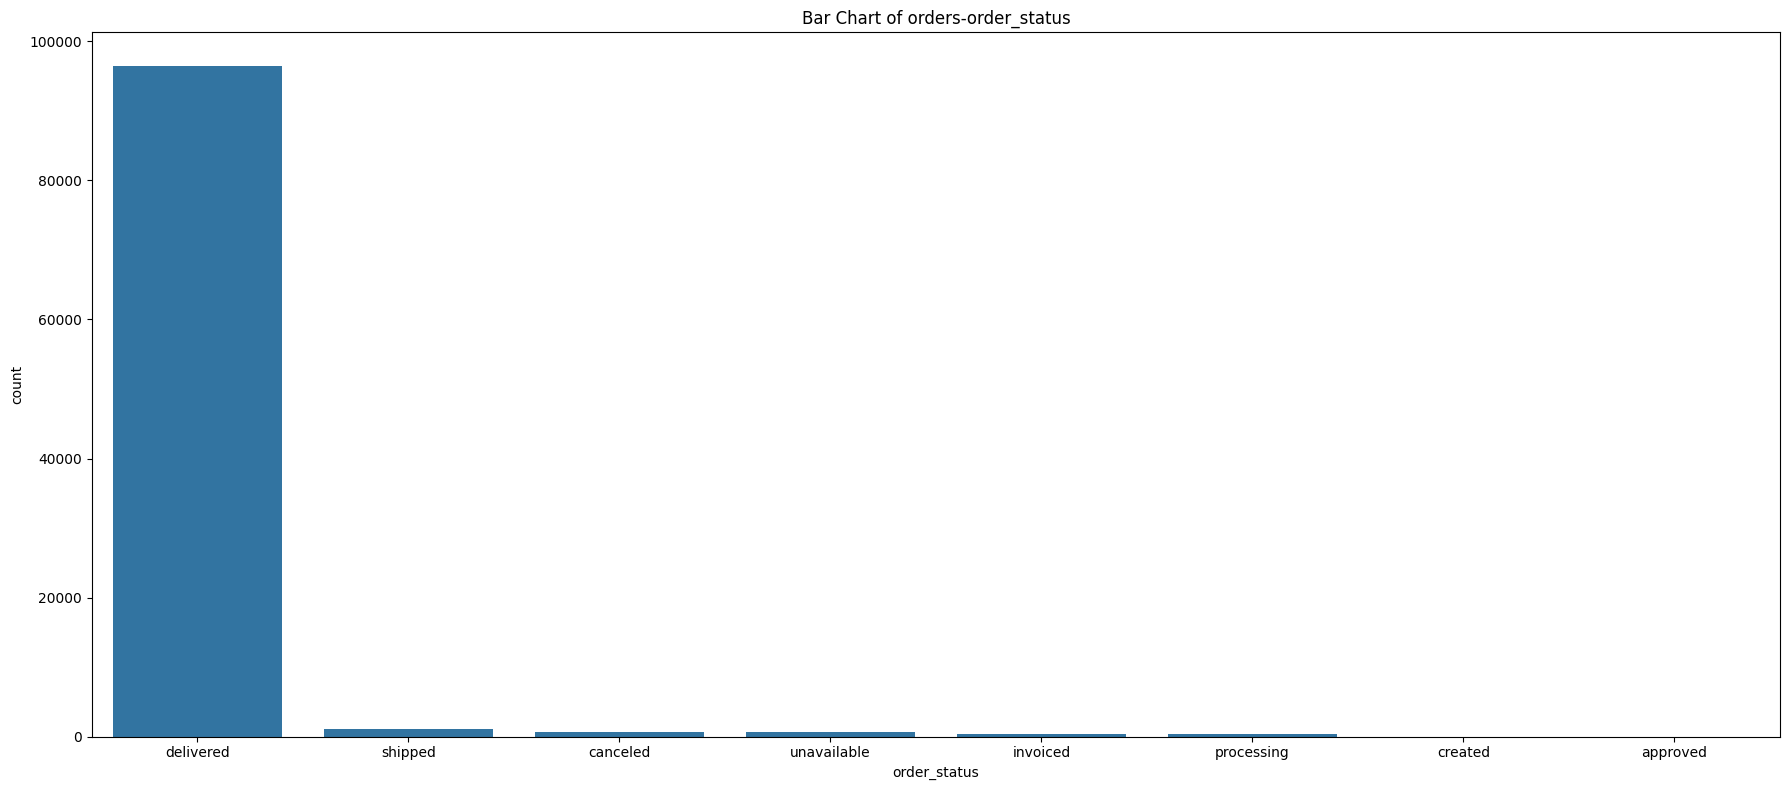


Frequency Count for products-product_category_name:
 product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
tablets_impressao_imagem            9
fashion_roupa_infanto_juvenil       5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 72, dtype: int64


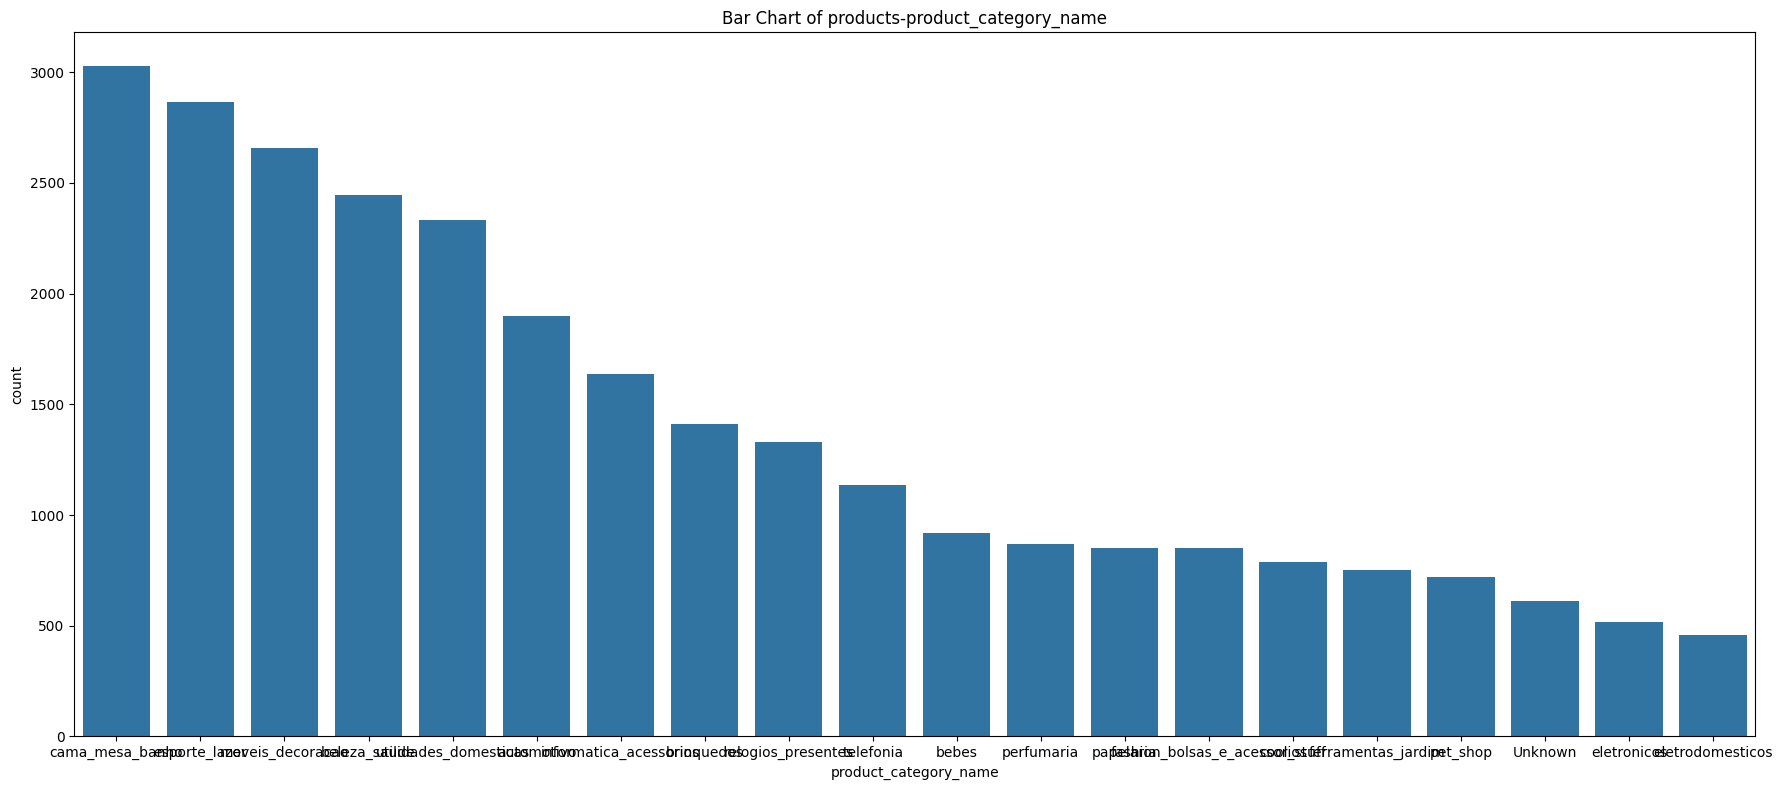


Frequency Count for sellers-seller_city:
 seller_city
sao paulo                 703
curitiba                  127
rio de janeiro             98
belo horizonte             69
ribeirao preto             55
                         ... 
aparecida de goiania        1
bandeirantes                1
vitoria de santo antao      1
palotina                    1
leme                        1
Name: count, Length: 572, dtype: int64


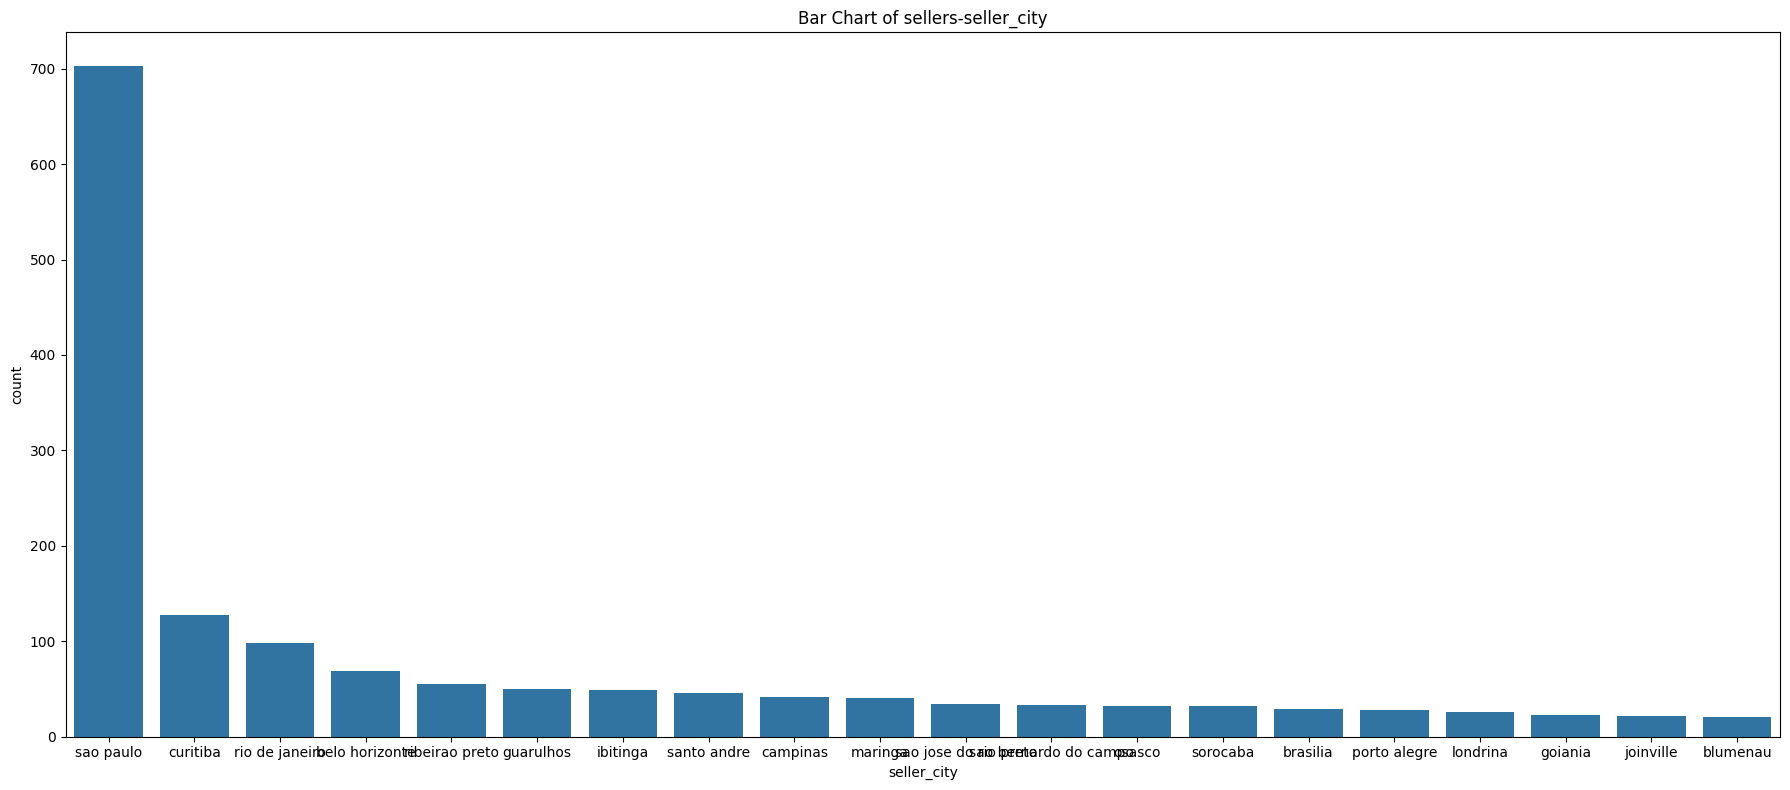


Frequency Count for sellers-seller_state:
 seller_state
SP    1823
PR     358
MG     249
SC     195
RJ     176
RS     131
GO      40
DF      30
ES      24
BA      20
CE      13
PE       9
PB       6
MS       5
MT       4
RN       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
Name: count, dtype: int64


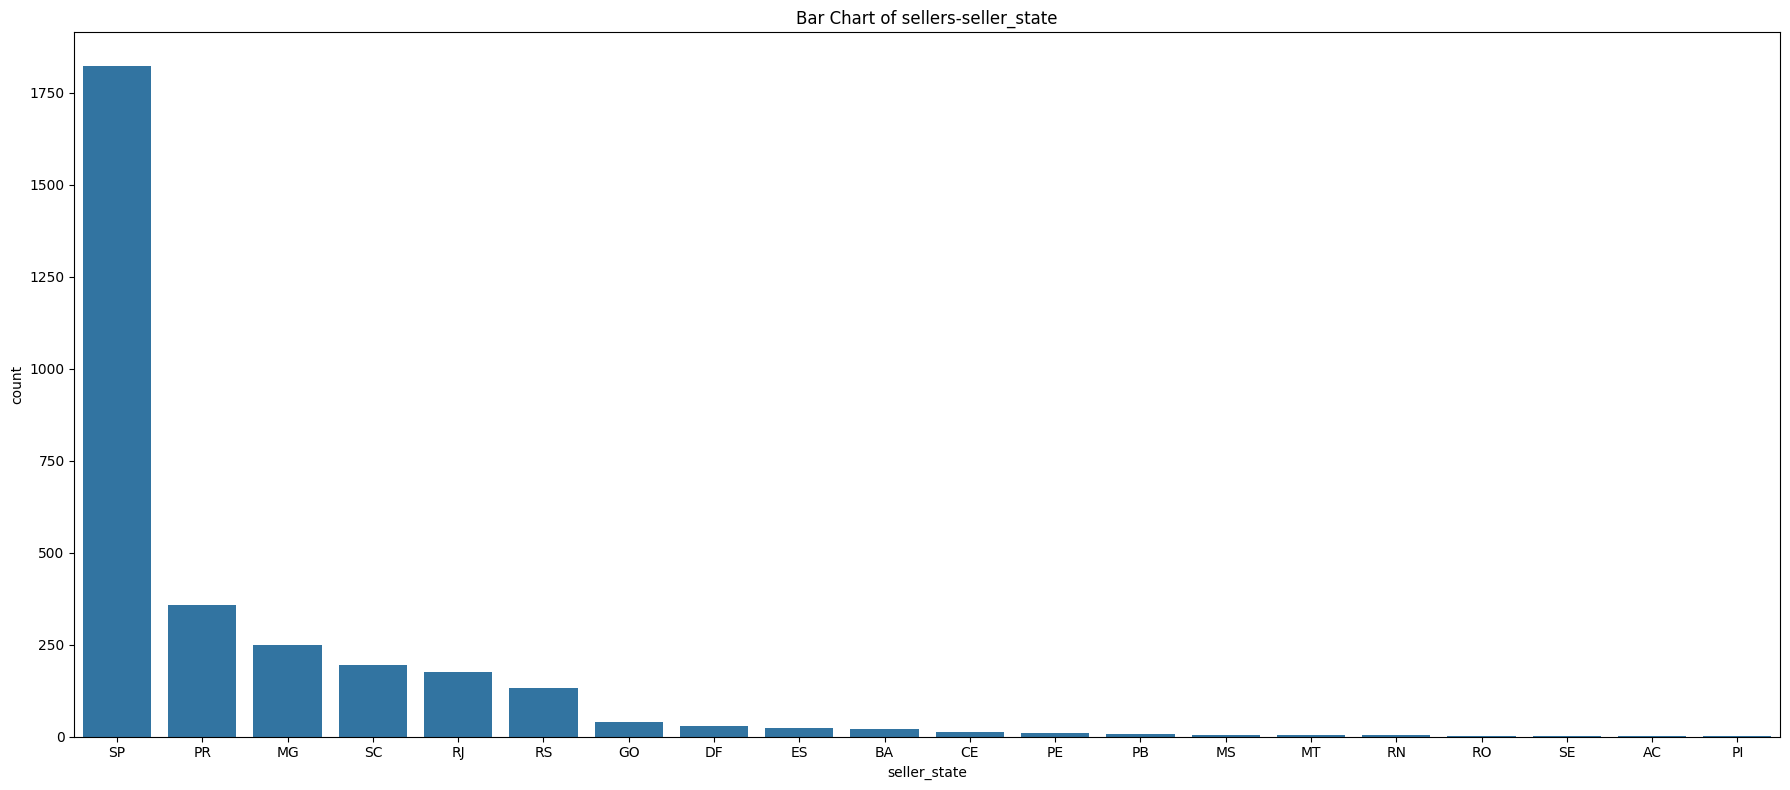

In [33]:
datsets = {
    "customers" : customers,
        "geolocation" : geolocation,
        "order_items" : order_items,
        "order_payments" : order_payments,
        "order_reviews" : order_reviews,
        "orders" : orders,
        "products" : products,
        "sellers" : sellers
}
for name, df in datsets.items():
    categorical_columns = df.select_dtypes(include = str).columns

    for col in categorical_columns:
        if 'id' in col.lower() or 'comment' in col.lower():
            continue

        print(f'\nFrequency Count for {name}-{col}:\n', df[col].value_counts())
        plt.figure(figsize=(18, 8))
        sns.countplot(x = col, data = df, order=df[col].value_counts().head(20).index)
        plt.title(f'Bar Chart of {name}-{col}')
        plt.tight_layout()
        plt.show()

#### DateTime Columns


Date Range for order_items-shipping_limit_date: 2016-09-19 00:15:34 to 2020-04-09 22:35:08

Time Span: 1298 days


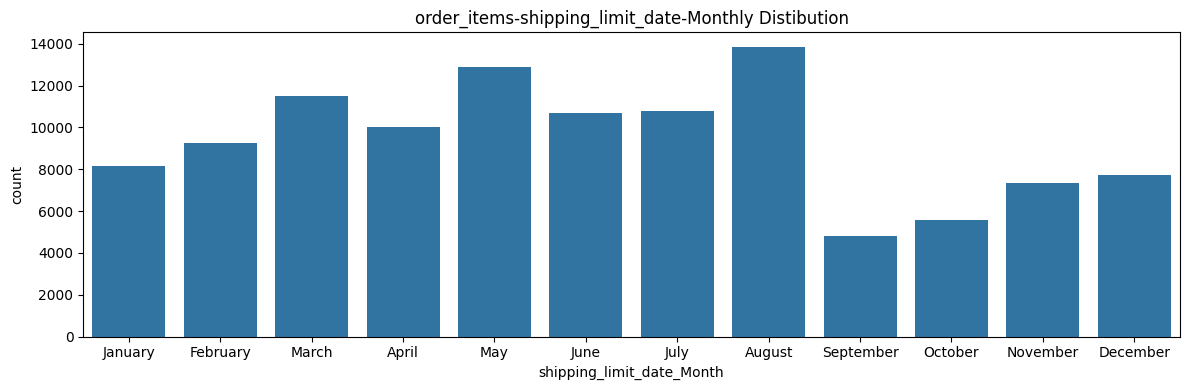

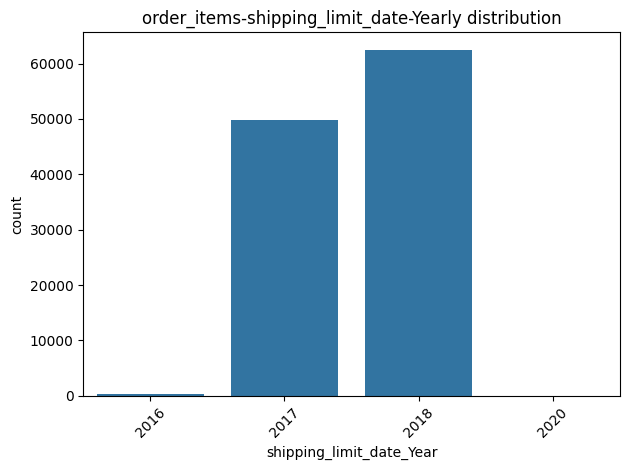


Date Range for order_reviews-review_creation_date: 2016-10-02 00:00:00 to 2018-08-31 00:00:00

Time Span: 698 days


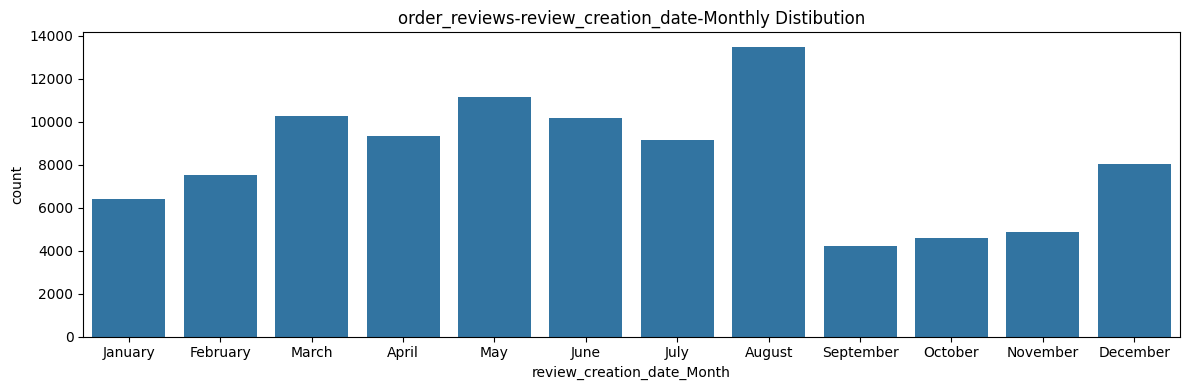

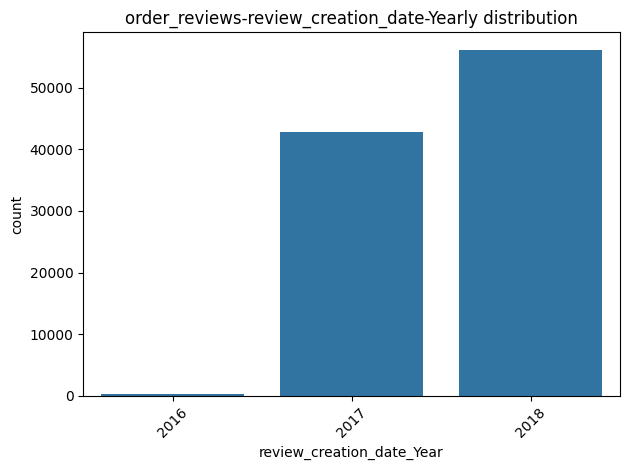


Date Range for order_reviews-review_answer_timestamp: 2016-10-07 18:32:28 to 2018-10-29 12:27:35

Time Span: 751 days


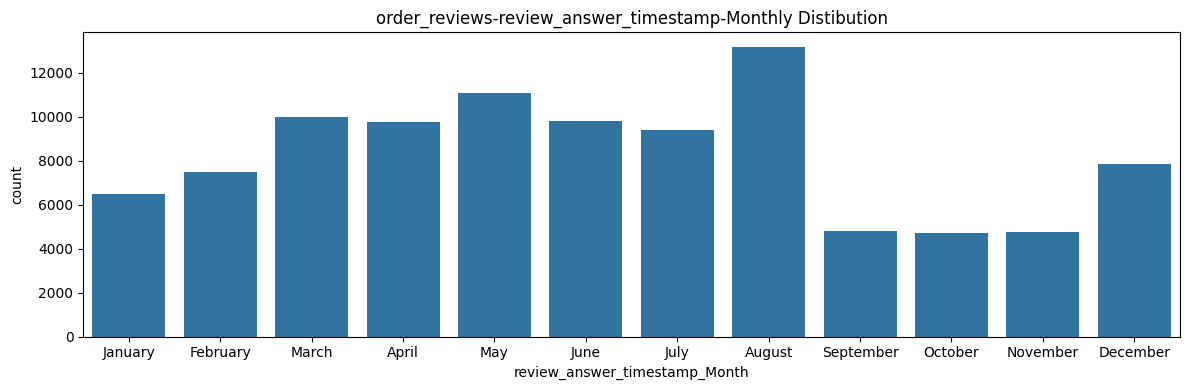

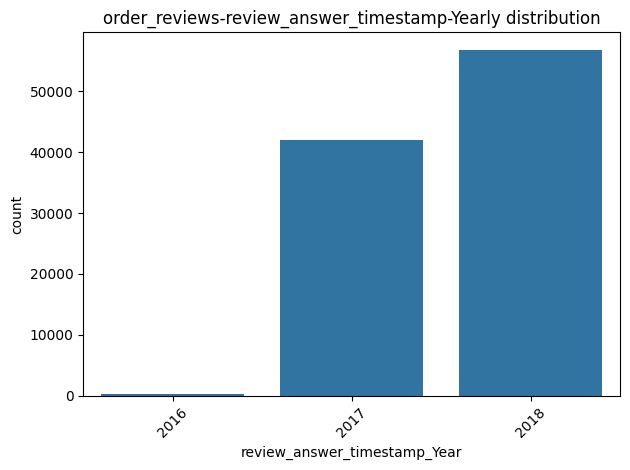


Date Range for orders-order_purchase_timestamp: 2016-09-04 21:15:19 to 2018-10-17 17:30:18

Time Span: 772 days


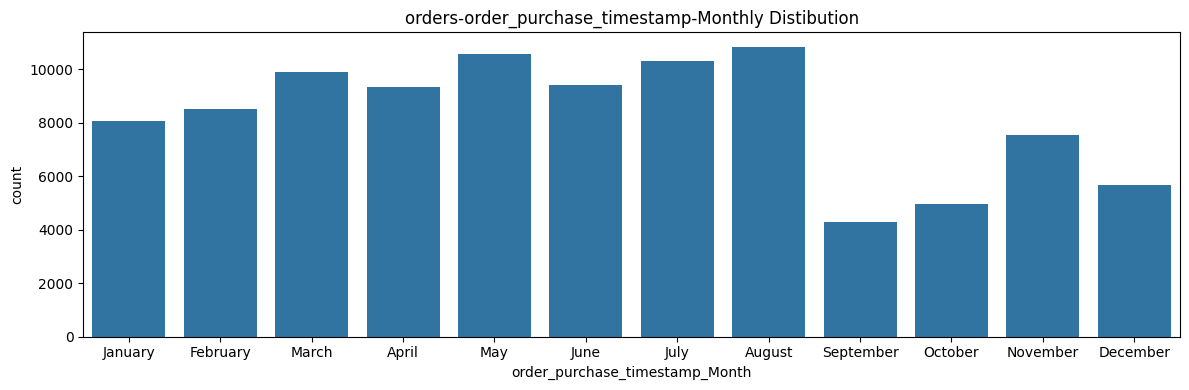

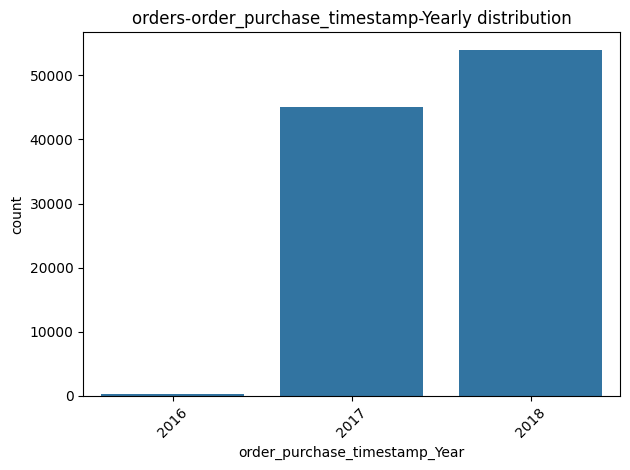


Date Range for orders-order_approved_at: 2016-09-15 12:16:38 to 2018-09-03 17:40:06

Time Span: 718 days


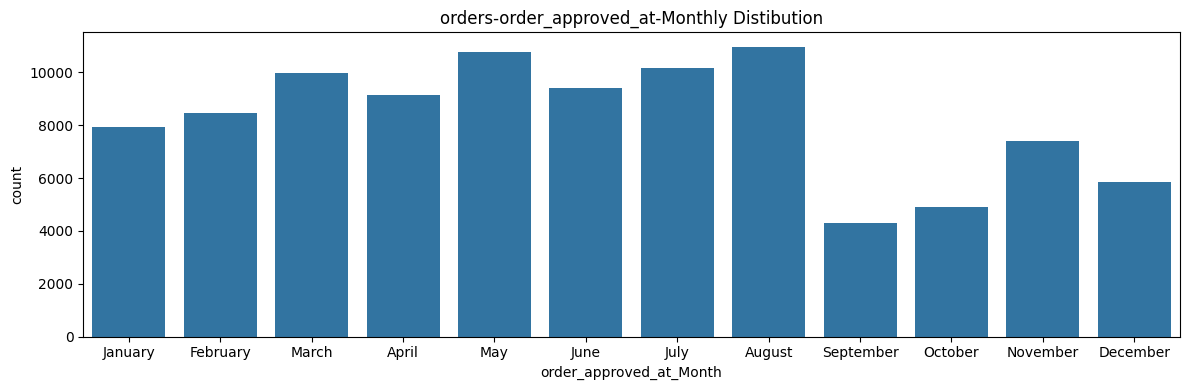

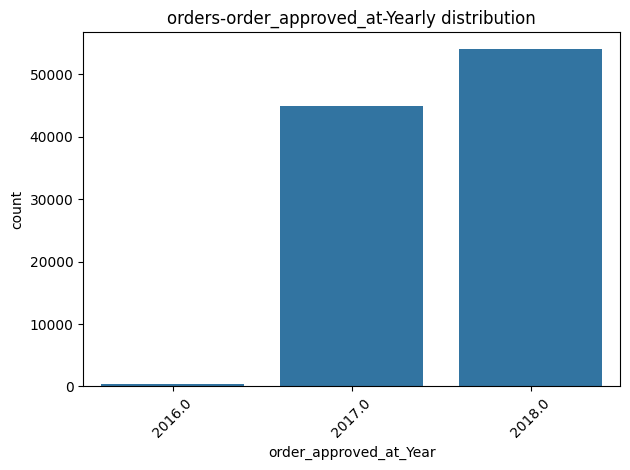


Date Range for orders-order_delivered_carrier_date: 2016-10-08 10:34:01 to 2018-09-11 19:48:28

Time Span: 703 days


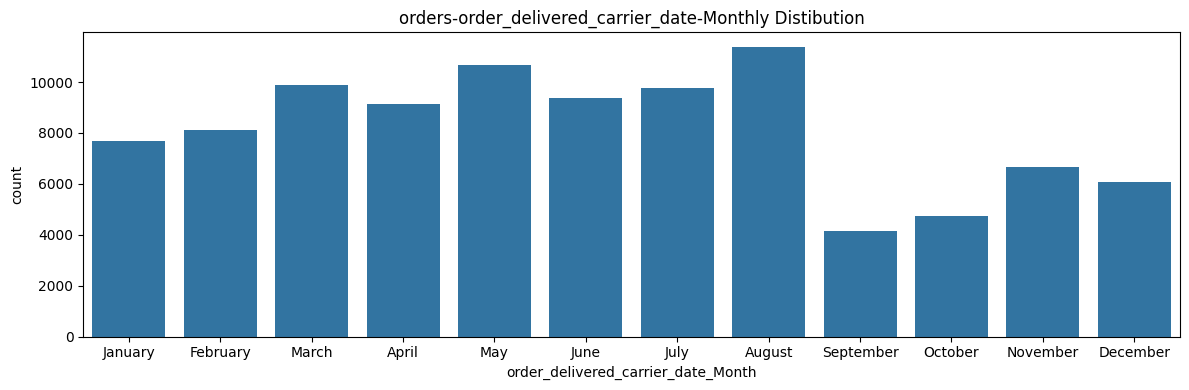

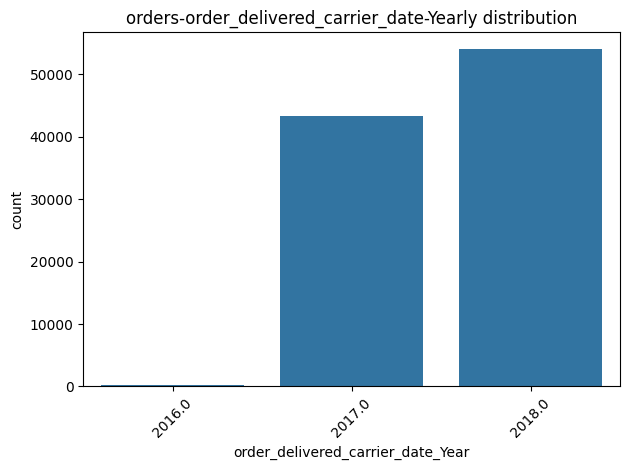


Date Range for orders-order_delivered_customer_date: 2016-10-11 13:46:32 to 2018-10-17 13:22:46

Time Span: 735 days


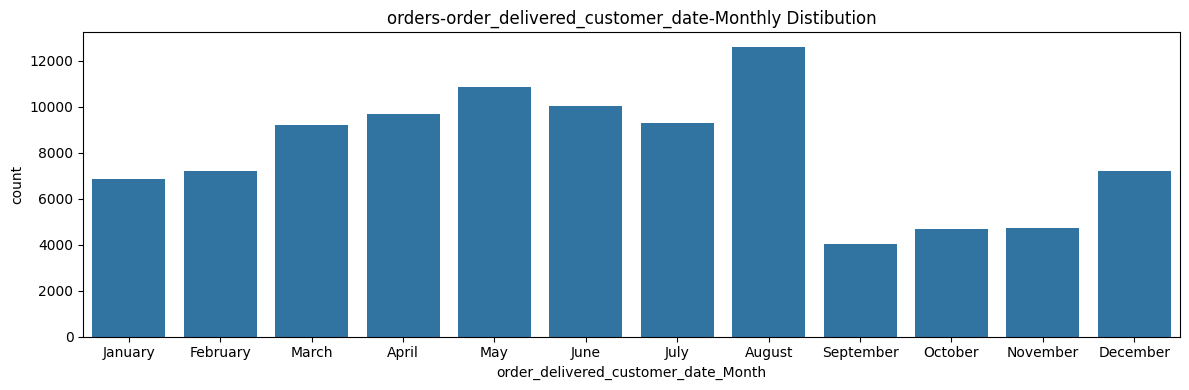

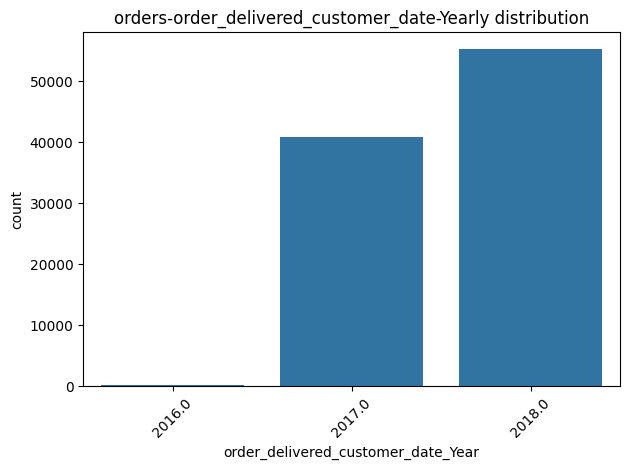


Date Range for orders-order_estimated_delivery_date: 2016-09-30 00:00:00 to 2018-11-12 00:00:00

Time Span: 773 days


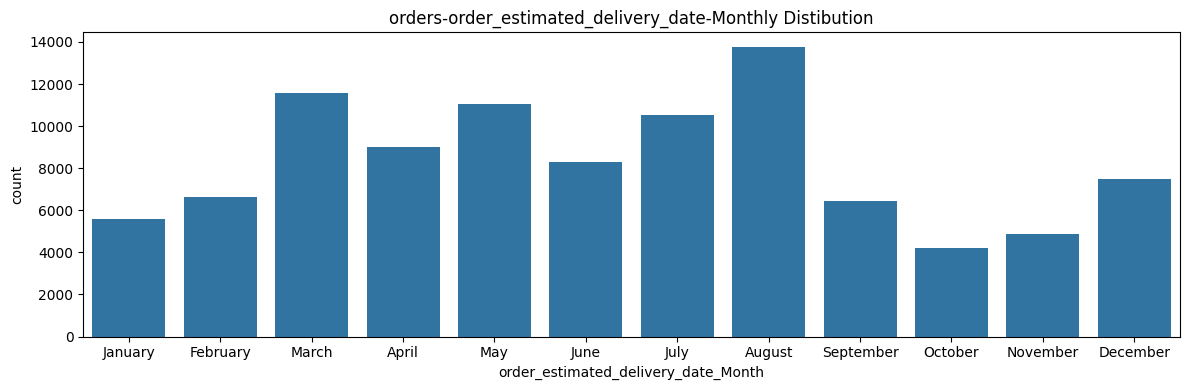

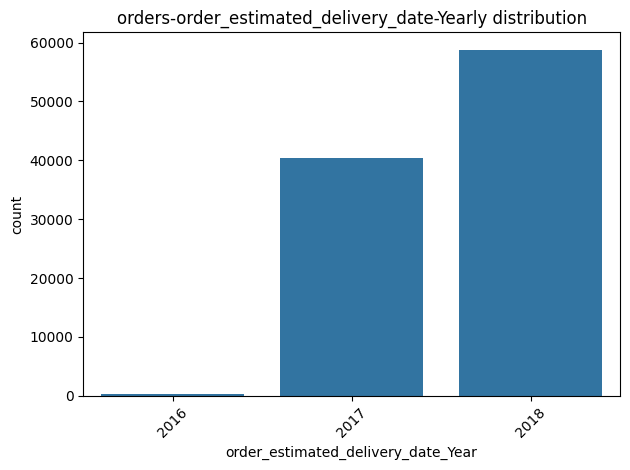

In [34]:
datsets = {
    "customers" : customers,
        "geolocation" : geolocation,
        "order_items" : order_items,
        "order_payments" : order_payments,
        "order_reviews" : order_reviews,
        "orders" : orders,
        "products" : products,
        "sellers" : sellers
}
## Monthly Distribution
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
for name, df in datsets.items():
    datetime_columns = df.select_dtypes(include = "datetime64").columns

    if len(datetime_columns) == 0:
        continue

    for col in datetime_columns:
        print(f'\nDate Range for {name}-{col}: {df[col].min()} to {df[col].max()}')
        print(f'\nTime Span: {(df[col].max() - df[col].min()).days} days')

        month_col = col + '_Month'
        df[month_col] = df[col].dt.month_name()

        year_col = col + '_Year'
        df[year_col] = df[col].dt.year

        plt.figure(figsize=(12, 4))
        sns.countplot(x = month_col, data = df, order = months)
        plt.title(f'{name}-{col}-Monthly Distibution')

        plt.tight_layout()
        plt.show()

        sns.countplot(x = year_col, data = df)
        plt.title(f'{name}-{col}-Yearly distribution')

        plt.xticks(rotation = 45)
        plt.tight_layout()
        plt.show()

    
    
     

In [35]:
datsets = {
    "customers" : customers,
        "geolocation" : geolocation,
        "order_items" : order_items,
        "order_payments" : order_payments,
        "order_reviews" : order_reviews,
        "orders" : orders,
        "products" : products,
        "sellers" : sellers
}
for name, df in datsets.items():
    datetime_columns = df.select_dtypes(include = "datetime64").columns

    if len(datetime_columns) == 0:
        continue

    for col in datetime_columns:
        diffs = df[col].sort_values().diff().dt.days.value_counts()
        print(diffs)


shipping_limit_date
0.0      112553
2.0          74
1.0          11
3.0           5
18.0          1
57.0          1
12.0          1
4.0           1
502.0         1
64.0          1
Name: count, dtype: int64
review_creation_date
0.0    98589
1.0      607
2.0       13
3.0        6
4.0        4
6.0        2
9.0        1
8.0        1
Name: count, dtype: int64
review_answer_timestamp
0.0    99187
1.0       23
2.0        6
3.0        3
4.0        2
6.0        1
5.0        1
Name: count, dtype: int64
order_purchase_timestamp
0.0     99423
2.0         5
1.0         2
3.0         2
4.0         2
8.0         1
17.0        1
11.0        1
62.0        1
12.0        1
13.0        1
Name: count, dtype: int64
order_approved_at
0.0     99270
1.0         3
4.0         2
18.0        1
66.0        1
12.0        1
2.0         1
5.0         1
Name: count, dtype: int64
order_delivered_carrier_date
0.0     97543
1.0        91
2.0        16
3.0         2
9.0         1
6.0         1
20.0        1
10.0        1


C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_4000\102983510.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order_items['Shipping_Month'] = pd.to_datetime(order_items['Shipping_Month'])


<Figure size 1200x800 with 0 Axes>

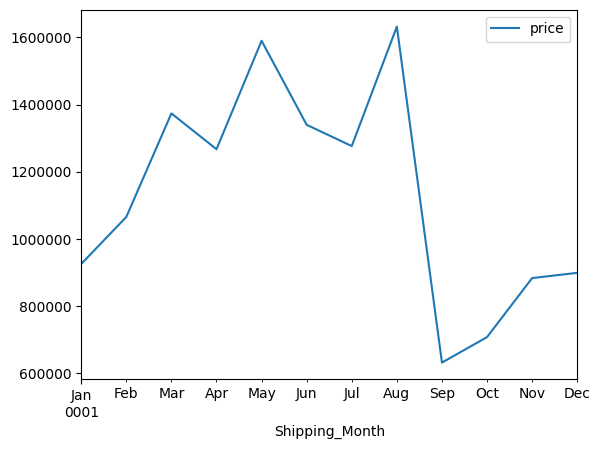

In [36]:
order_items['Shipping_Month'] = order_items['shipping_limit_date'].dt.month_name()
order_items['Shipping_Month'] = pd.to_datetime(order_items['Shipping_Month'])

plt.figure(figsize = (12, 8))
order_items.groupby('Shipping_Month')[['price']].sum().plot()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose

order_items['shipping_date'] = order_items['shipping_limit_date'].dt.date 

order_daily = order_items.groupby('shipping_date')[['price']].sum()

result = seasonal_decompose(order_daily, model='addictive', period=30)

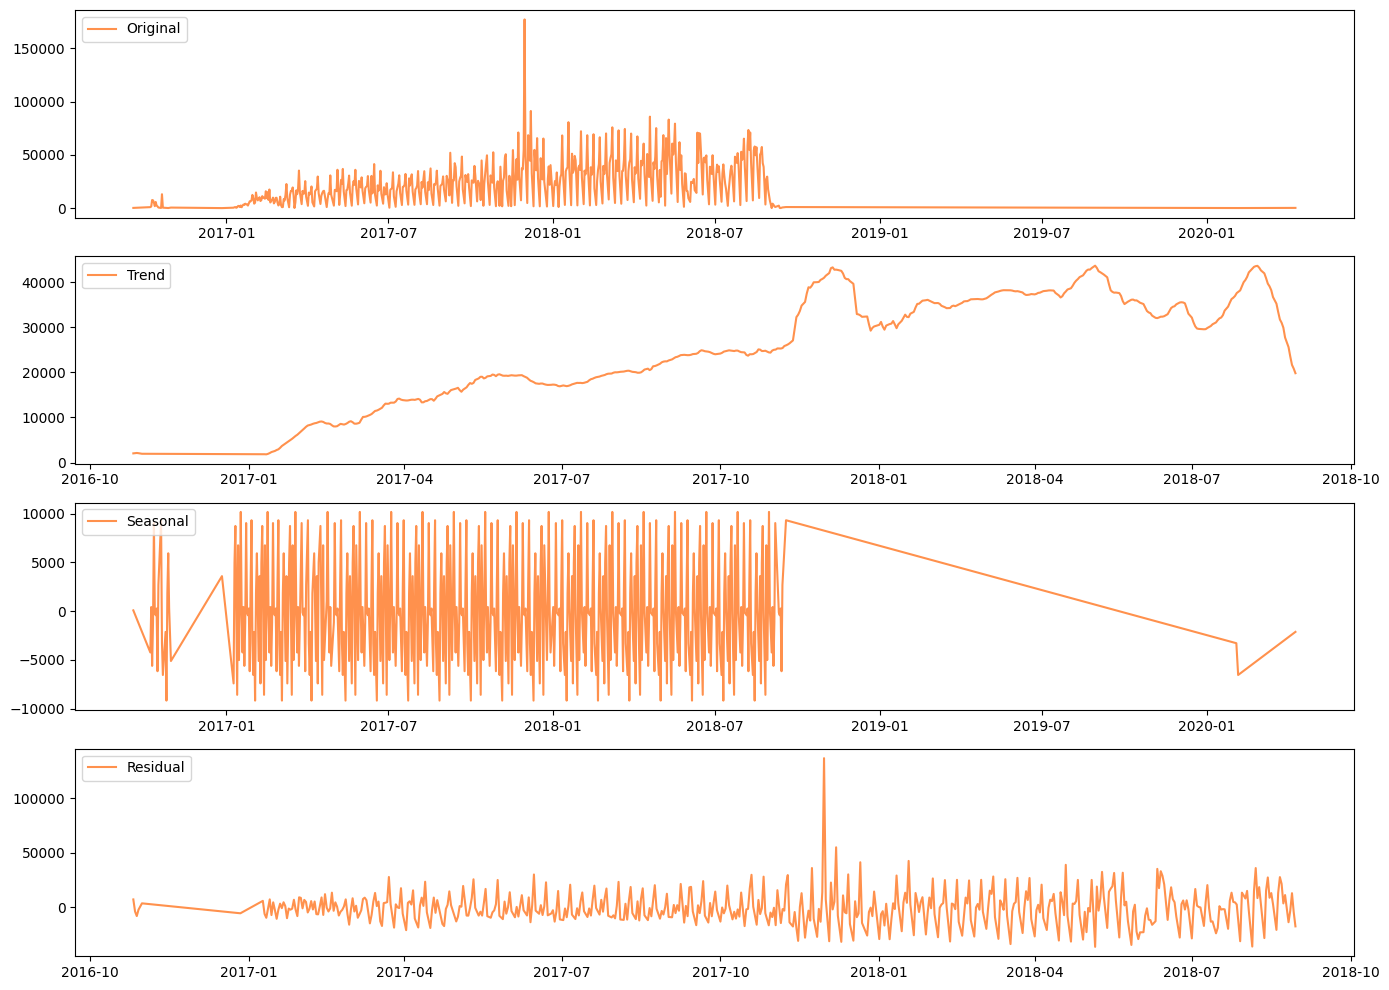

In [38]:
trend_additive = result.trend
seasonal_additive = result.seasonal
residual_error = result.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(order_daily, label = 'Original', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(412)
plt.plot(trend_additive, label = 'Trend', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(413)
plt.plot(seasonal_additive, label = 'Seasonal', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(414)
plt.plot(residual_error, label = 'Residual', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

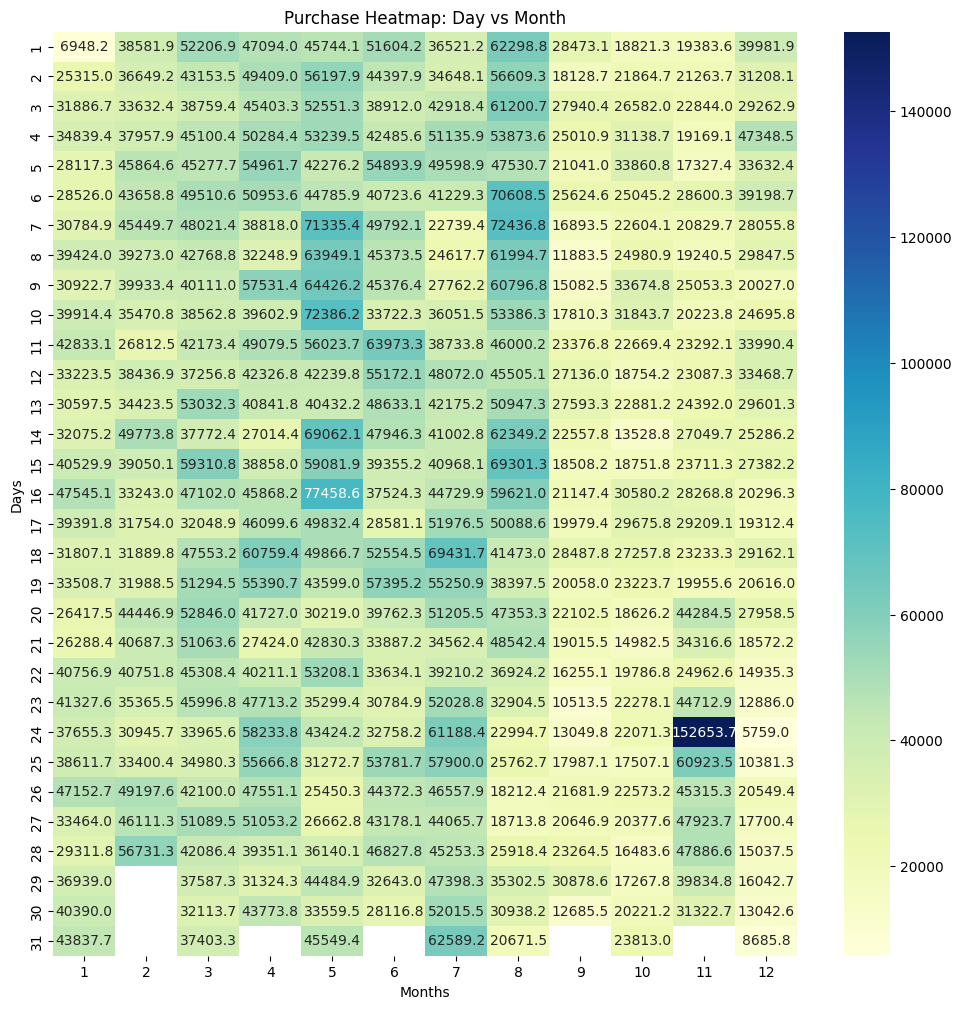

In [47]:
orders['Purchased_day'] = orders['order_purchase_timestamp'].dt.day
orders['Purchased_Month'] = orders['order_purchase_timestamp'].dt.month

purchase_dates = orders[['order_id', 'order_purchase_timestamp', 'Purchased_day', 'Purchased_Month' ]]
prices = order_items[['order_id', 'price']]

df = pd.merge(
    purchase_dates,
    prices,
    on = 'order_id',
    how = 'left'
    )

heatmap = df.pivot_table(
    index = 'Purchased_day',
    columns = 'Purchased_Month',
    values = 'price',
    aggfunc = 'sum'
)

plt.figure(figsize = (12, 12))
sns.heatmap(heatmap, cmap='YlGnBu', annot=True, fmt=".1f")
plt.xlabel('Months')
plt.ylabel('Days')
plt.title("Purchase Heatmap: Day vs Month")
plt.show()

### Text PreProcessing

In [19]:
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].str.lower().str.strip().str.replace(
    r'\s+','',regex=True).str.replace(r'[^\w\s]','',regex=True)

order_reviews.loc[order_reviews['review_comment_title'].str.fullmatch(r'\d+',na=False), 'review_comment_title'] = 'No Title'
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].replace('', 'No Title')

In [20]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]",'',text)
    return text
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].apply(clean_text)
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].replace('', 'no comment')
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].apply(clean_text)

In [58]:
order_reviews.to_csv(f"E:\Brazilian E-Commerce Public Dataset by Olist\Cleaned_Data\order_reviews_Cleaned.csv", index = False)

<>:1: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
<>:1: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_4000\3989752445.py:1: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
  order_reviews.to_csv(f"E:\Brazilian E-Commerce Public Dataset by Olist\Cleaned_Data\order_reviews_Cleaned.csv", index = False)


In [59]:
order_reviews['title_tokens'] = order_reviews['review_comment_title'].apply(lambda x : x.split())
order_reviews['title_token_counts'] = order_reviews['title_tokens'].apply(len) 

In [61]:
order_reviews['message_tokens'] = order_reviews['review_comment_message'].apply(lambda x : x.split())
order_reviews['message_token_counts'] = order_reviews['message_tokens'].apply(len)

In [63]:
order_reviews['message_token_counts'].describe()

count    99224.000000
mean         5.859228
std          7.501584
min          0.000000
25%          2.000000
50%          2.000000
75%          7.000000
max         42.000000
Name: message_token_counts, dtype: float64

In [65]:
from collections import Counter
from nltk.corpus import stopwords

stopword = set(stopwords.words('portuguese'))




### Top Ten Common Words in Reviews


Top 10 Most Common Words
        word  count
0    comment  58399
1    produto  18163
2      prazo   8262
3    entrega   6415
4      antes   5609
5     chegou   5468
6     recebi   5238
7        bom   4513
8  recomendo   4173
9   entregue   3750


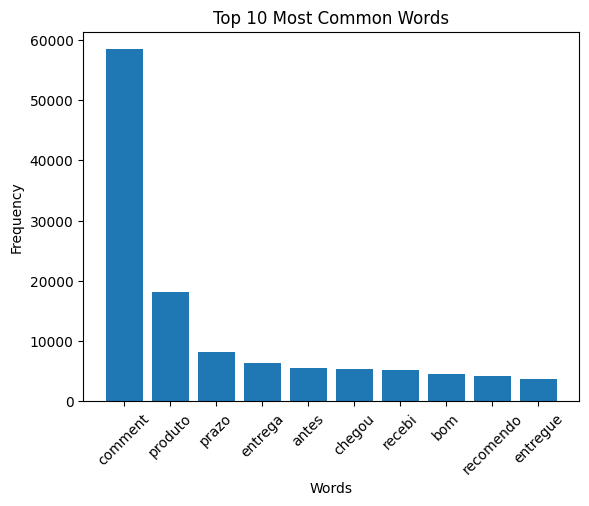

In [73]:
all_token = [token for tokens in order_reviews['message_tokens'] for token in tokens]

all_tokens = [token for token in all_token if token not in stopword]


word_freq = Counter(all_tokens)
top_words = word_freq.most_common(10)

top_words_df = pd.DataFrame(top_words, columns = ['word', 'count'])
print("\nTop 10 Most Common Words")
print(top_words_df)

plt.figure()
plt.bar(top_words_df['word'], top_words_df['count'])
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Common Words')
plt.xticks(rotation=45)
plt.show()



### Bivariate Analysis

#### Categorical - Numerical Column

In [22]:
cust_cat = customers[['customer_id', 'customer_city', 'customer_state']] 
ord_pym_cat = order_payments[['order_id', 'payment_type']]
ord_cat = orders[['order_id', 'customer_id', 'order_status']]
prod_cat = products[['product_id', 'product_category_name']]
sell_cat = sellers[['seller_id', 'seller_city', 'seller_state']]
ord_item_cat = order_items[['order_id', 'product_id', 'seller_id']]

order_items_num = order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']]
order_pym_num = order_payments[['order_id', 'payment_sequential', 'payment_installments', 'payment_value']]

In [23]:
df = ord_cat.merge(cust_cat, on = 'customer_id', how = 'left')

In [24]:
df =df.merge(ord_pym_cat, on = 'order_id', how = 'left')

In [25]:
df =df.merge(ord_item_cat, on = 'order_id', how = 'left')

In [26]:
df = df.merge(prod_cat, on = 'product_id', how = 'left')

In [27]:
df = df.merge(sell_cat, on = 'seller_id', how = 'left')

In [28]:
num_df = order_items_num.merge(order_pym_num, on = 'order_id', how = 'left')

In [29]:
full_df = df.merge(num_df, on = 'order_id', how = 'left')

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

...

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

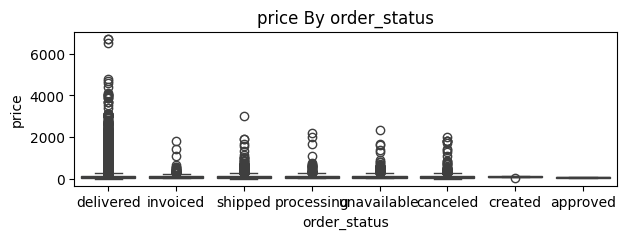


 Group Mean and Median of price by order_status:
                    mean   median   count
order_status                             
approved       49.860000   19.850       5
canceled      161.588122   79.000     996
created              NaN      NaN       0
delivered     109.013471   69.000  188872
invoiced      138.418151   65.500     557
processing    145.708355   54.900     681
shipped       216.312004  144.995    2350
unavailable   240.742222   99.000       9


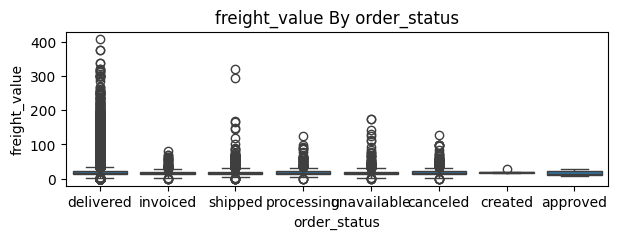


 Group Mean and Median of freight_value by order_status:
                   mean  median   count
order_status                           
approved      10.680000  10.960       5
canceled      18.242641  15.110     996
created             NaN     NaN       0
delivered     19.766171  16.220  188872
invoiced      19.141849  15.100     557
processing    24.125521  15.660     681
shipped       37.222702  23.805    2350
unavailable   18.444444  20.850       9


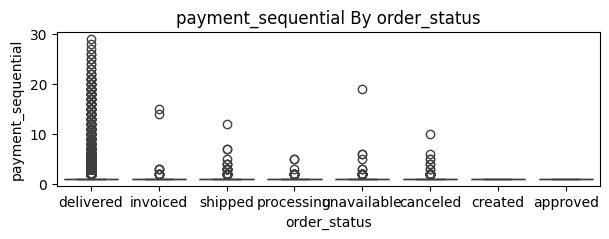


 Group Mean and Median of payment_sequential by order_status:
                  mean  median   count
order_status                          
approved      1.000000     1.0       5
canceled      1.362450     1.0     996
created            NaN     NaN       0
delivered     1.703637     1.0  188863
invoiced      1.068223     1.0     557
processing    1.696035     1.0     681
shipped       6.054043     1.0    2350
unavailable   1.000000     1.0       9


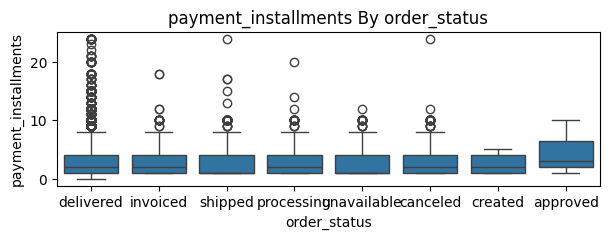


 Group Mean and Median of payment_installments by order_status:
                  mean  median   count
order_status                          
approved      1.800000     1.0       5
canceled      3.063253     1.0     996
created            NaN     NaN       0
delivered     2.865103     1.0  188863
invoiced      2.359066     1.0     557
processing    2.997063     1.0     681
shipped       2.532766     1.0    2350
unavailable   5.444444     7.0       9


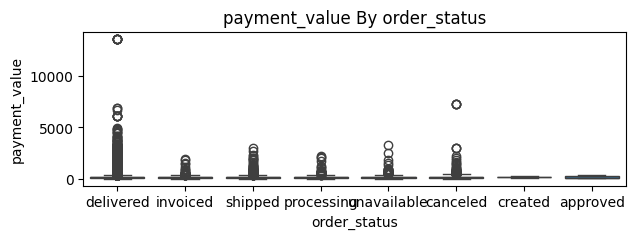


 Group Mean and Median of payment_value by order_status:
                    mean   median   count
order_status                             
approved       85.188000   61.620       5
canceled      345.304528  133.980     996
created              NaN      NaN       0
delivered     212.971844  113.620  188863
invoiced      227.438761  145.560     557
processing    337.007680  158.450     681
shipped       117.477421   64.035    2350
unavailable   301.895556  192.190       9


<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

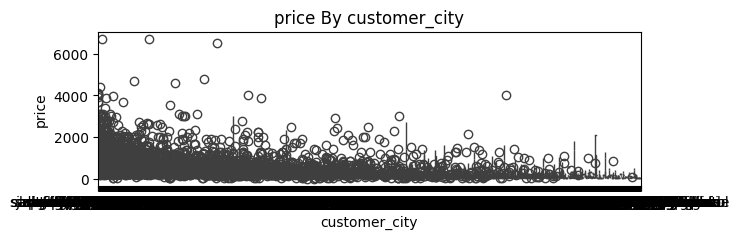


 Group Mean and Median of price by customer_city:
                           mean   median  count
customer_city                                  
abadia dos dourados  119.633333  120.000      3
abadiania            949.990000  949.990      1
abaete               144.400833  117.450     12
abaetetuba           210.738800  179.900     25
abaiara              131.450000  131.450      2
...                         ...      ...    ...
xinguara             110.518333   41.495     12
xique-xique           59.930000   40.990      3
zacarias              99.400000   99.400      2
ze doca              137.720000   74.800      5
zortea                49.900000   49.900      2

[4119 rows x 3 columns]


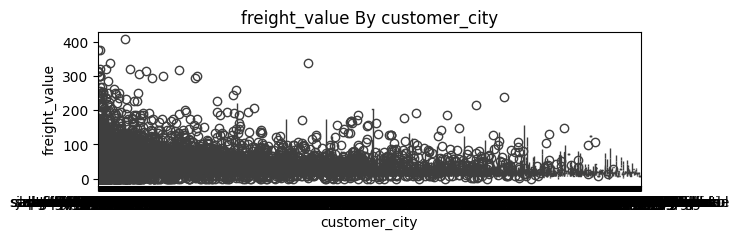


 Group Mean and Median of freight_value by customer_city:
                          mean  median  count
customer_city                                
abadia dos dourados  18.200000  18.380      3
abadiania            75.530000  75.530      1
abaete               17.833333  17.940     12
abaetetuba           46.805200  46.830     25
abaiara              34.625000  34.625      2
...                        ...     ...    ...
xinguara             33.367500  37.060     12
xique-xique          16.923333  16.790      3
zacarias             15.525000  15.525      2
ze doca              38.064000  38.070      5
zortea               18.885000  18.885      2

[4119 rows x 3 columns]


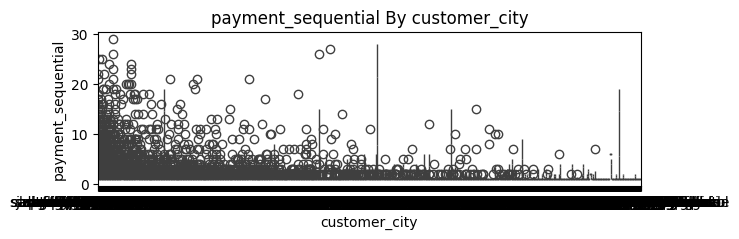


 Group Mean and Median of payment_sequential by customer_city:
                     mean  median  count
customer_city                           
abadia dos dourados  1.00     1.0      3
abadiania            1.00     1.0      1
abaete               1.00     1.0     12
abaetetuba           1.08     1.0     25
abaiara              1.00     1.0      2
...                   ...     ...    ...
xinguara             1.00     1.0     12
xique-xique          1.00     1.0      3
zacarias             1.00     1.0      2
ze doca              1.00     1.0      5
zortea               1.00     1.0      2

[4119 rows x 3 columns]


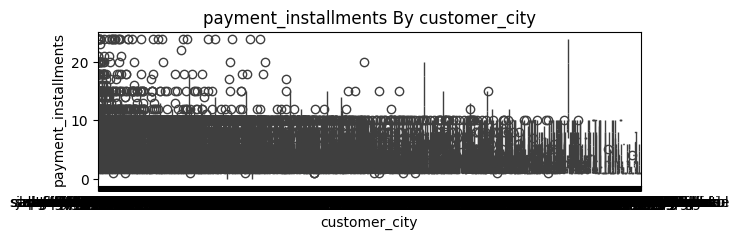


 Group Mean and Median of payment_installments by customer_city:
                     mean  median  count
customer_city                           
abadia dos dourados  4.00     1.0      3
abadiania            8.00     8.0      1
abaete               3.50     2.5     12
abaetetuba           7.12    10.0     25
abaiara              4.00     4.0      2
...                   ...     ...    ...
xinguara             3.50     1.0     12
xique-xique          1.00     1.0      3
zacarias             6.00     6.0      2
ze doca              3.20     2.0      5
zortea               1.50     1.5      2

[4119 rows x 3 columns]


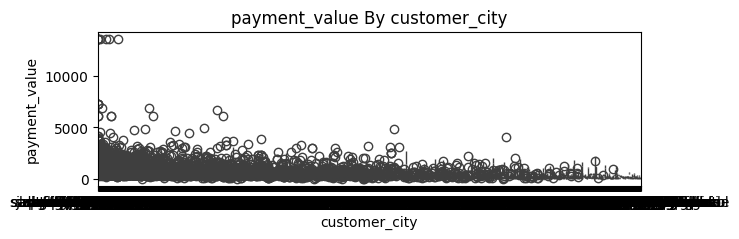


 Group Mean and Median of payment_value by customer_city:
                            mean    median  count
customer_city                                    
abadia dos dourados   137.833333   135.590      3
abadiania            1025.520000  1025.520      1
abaete                162.234167   135.945     12
abaetetuba            433.472000   283.660     25
abaiara               166.075000   166.075      2
...                          ...       ...    ...
xinguara              163.572500   118.120     12
xique-xique            76.853333    57.780      3
zacarias              114.925000   114.925      2
ze doca               175.784000   112.870      5
zortea                 68.785000    68.785      2

[4119 rows x 3 columns]


<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

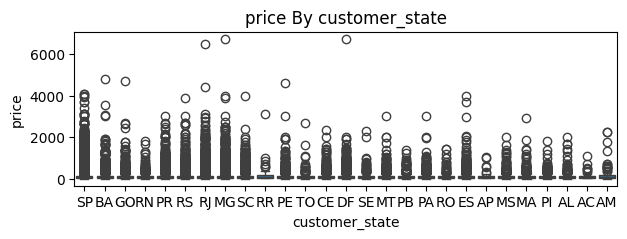


 Group Mean and Median of price by customer_state:
                      mean  median  count
customer_state                           
AC              157.782313   79.90    147
AL              172.604099  113.00    588
AM              115.519880   84.00    249
AP              140.020308   89.90    130
BA              127.388084   79.00   6430
CE              146.258701   85.90   2355
DF              115.187680   69.90   3487
ES              116.054021   69.90   3258
GO              118.058764   79.45   4416
MA              145.364026   80.02   1150
MG              107.601525   68.00  20422
MS              121.318804   74.90   1263
MT              191.540805  105.00   3017
PA              151.566161   95.90   1524
PB              177.795724   99.90    987
PE              128.852752   75.00   2591
PI              162.386493  108.00    787
PR              106.329852   65.49   9380
RJ              114.946774   79.98  25483
RN              199.915088   98.00    853
RO              137.9727

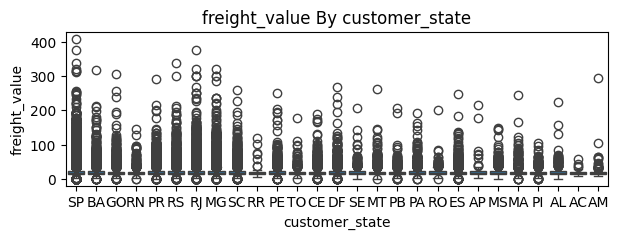


 Group Mean and Median of freight_value by customer_state:
                     mean  median  count
customer_state                          
AC              36.430748  27.840    147
AL              34.647415  31.970    588
AM              32.784779  25.540    249
AP              32.337154  27.590    130
BA              27.658053  20.290   6430
CE              30.484667  26.320   2355
DF              20.426461  16.700   3487
ES              21.398100  17.815   3258
GO              20.970865  17.610   4416
MA              38.530722  34.150   1150
MG              20.225364  17.320  20422
MS              21.776144  18.090   1263
MT              37.287212  23.560   3017
PA              35.278734  28.805   1524
PB              49.386727  34.150    987
PE              32.457808  27.050   2591
PI              39.880114  34.650    787
PR              20.967371  16.950   9380
RJ              21.714621  17.850  25483
RN              32.602685  29.700    853
RO              38.353706  34.150    3

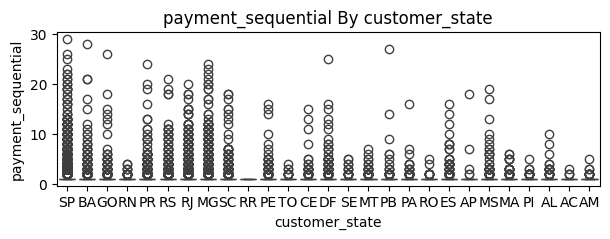


 Group Mean and Median of payment_sequential by customer_state:
                    mean  median  count
customer_state                         
AC              1.040816     1.0    147
AL              1.078231     1.0    588
AM              1.120482     1.0    249
AP              1.030769     1.0    130
BA              1.357387     1.0   6430
CE              1.245011     1.0   2355
DF              1.069974     1.0   3487
ES              1.108656     1.0   3258
GO              1.208560     1.0   4416
MA              1.059130     1.0   1150
MG              1.169425     1.0  20422
MS              1.098179     1.0   1263
MT              5.214451     1.0   3017
PA              1.076772     1.0   1524
PB              1.155015     1.0    987
PE              1.154766     1.0   2591
PI              1.102922     1.0    787
PR              1.237313     1.0   9380
RJ              1.879174     1.0  25483
RN              1.409144     1.0    853
RO              1.053299     1.0    394
RR             

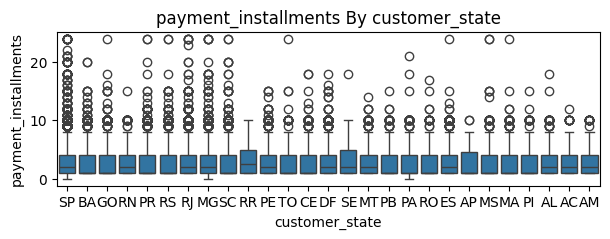


 Group Mean and Median of payment_installments by customer_state:
                    mean  median  count
customer_state                         
AC              3.653061     3.0    147
AL              4.409864     3.0    588
AM              3.036145     1.0    249
AP              2.661538     2.0    130
BA              3.322084     2.0   6430
CE              3.825478     3.0   2355
DF              3.031833     1.0   3487
ES              2.873542     1.0   3258
GO              3.538270     2.0   4416
MA              3.002609     1.0   1150
MG              3.083537     1.0  20422
MS              2.784640     1.0   1263
MT              2.680477     1.0   3017
PA              3.512467     2.0   1524
PB              3.364742     2.0    987
PE              3.485913     2.0   2591
PI              3.454892     2.0    787
PR              3.218870     1.0   9380
RJ              2.814661     1.0  25483
RN              3.439625     2.0    853
RO              3.324873     2.0    394
RR           

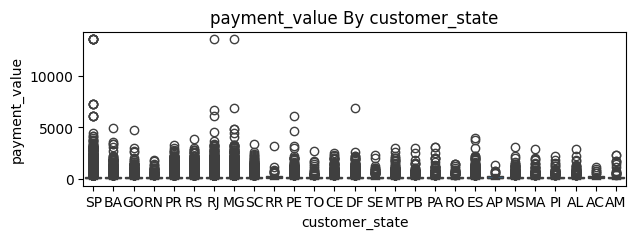


 Group Mean and Median of payment_value by customer_state:
                      mean   median  count
customer_state                            
AC              346.443401  289.390    147
AL              278.505289  160.225    588
AM              243.746305  173.020    249
AP              286.868231  255.040    130
BA              257.707014  119.930   6430
CE              277.464170  151.640   2355
DF              202.693112  133.690   3487
ES              213.513048  122.030   3258
GO              473.412117  167.815   4416
MA              354.700643  157.555   1150
MG              204.112748  127.025  20422
MS              211.937371  157.320   1263
MT              198.388137   67.490   3017
PA              270.441870  169.620   1524
PB              374.248308  175.600    987
PE              209.296148  142.890   2591
PI              301.641576  168.810    787
PR              255.441323  130.005   9380
RJ              225.242622  112.420  25483
RN              202.962087  140.300  

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

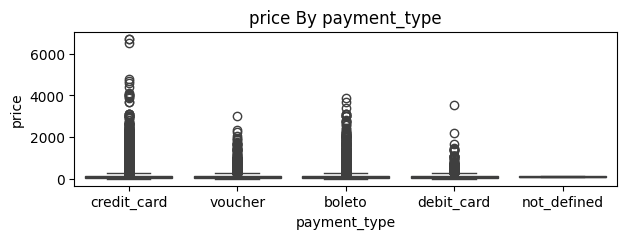


 Group Mean and Median of price by payment_type:
                    mean  median   count
payment_type                            
boleto         98.308769    59.9   34413
credit_card   114.961282    69.9  124607
debit_card     97.029968    53.0    2218
not_defined          NaN     NaN       0
voucher       109.049810    69.9   32223


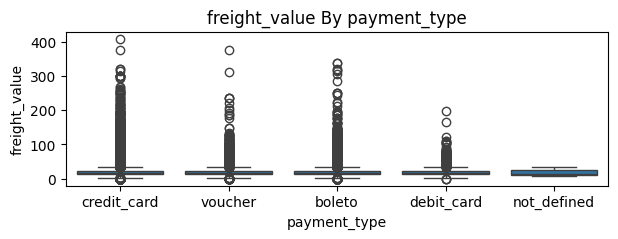


 Group Mean and Median of freight_value by payment_type:
                   mean  median   count
payment_type                           
boleto        19.661176   16.11   34413
credit_card   19.705900   16.15  124607
debit_card    17.483129   14.52    2218
not_defined         NaN     NaN       0
voucher       21.578810   17.59   32223


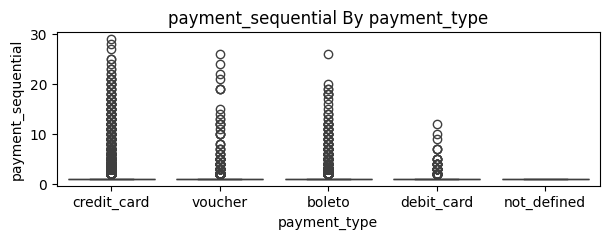


 Group Mean and Median of payment_sequential by payment_type:
                  mean  median   count
payment_type                          
boleto        1.000029     1.0   34413
credit_card   1.079715     1.0  124607
debit_card    1.029757     1.0    2218
not_defined        NaN     NaN       0
voucher       5.209447     3.0   32223


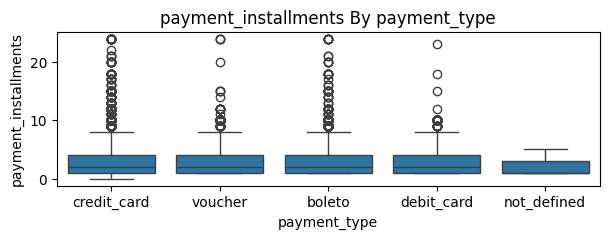


 Group Mean and Median of payment_installments by payment_type:
                  mean  median   count
payment_type                          
boleto        1.000000     1.0   34413
credit_card   3.840844     3.0  124607
debit_card    1.000902     1.0    2218
not_defined        NaN     NaN       0
voucher       1.188561     1.0   32223


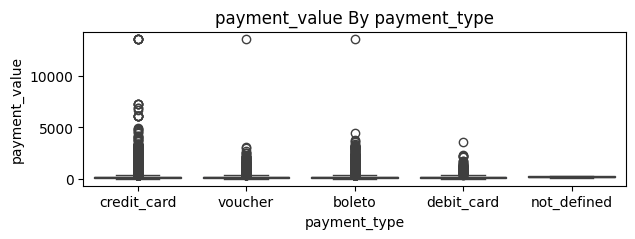


 Group Mean and Median of payment_value by payment_type:
                    mean  median   count
payment_type                            
boleto        300.133991  144.31   34413
credit_card   234.034411  136.20  124607
debit_card    169.392579  121.67    2218
not_defined          NaN     NaN       0
voucher        41.438590   16.70   32223


<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

...

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

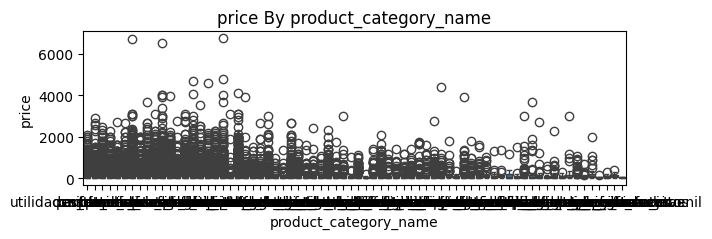


 Group Mean and Median of price by product_category_name:
                                 mean  median  count
product_category_name                               
Unknown                    104.020662   69.99   2809
agro_industria_e_comercio  321.948112  412.00   1128
alimentos                   50.767503   33.89    773
alimentos_bebidas           52.378143   34.99    490
artes                       96.247812   69.99    288
...                               ...     ...    ...
sinalizacao_e_seguranca    115.002948   59.90    424
tablets_impressao_imagem    90.504722   99.00    108
telefonia                   72.220625   29.99   6542
telefonia_fixa             414.552998  122.99    497
utilidades_domesticas       74.456525   49.00  14699

[72 rows x 3 columns]


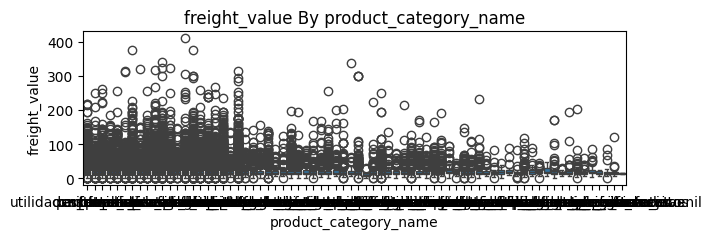


 Group Mean and Median of freight_value by product_category_name:
                                mean  median  count
product_category_name                              
Unknown                    21.135568   15.61   2809
agro_industria_e_comercio  27.725869   27.72   1128
alimentos                  13.859043   12.94    773
alimentos_bebidas          15.811796   15.11    490
artes                      19.071910   15.56    288
...                              ...     ...    ...
sinalizacao_e_seguranca    47.504623   17.81    424
tablets_impressao_imagem   15.122222   14.86    108
telefonia                  15.569375   15.10   6542
telefonia_fixa             18.842515   16.75    497
utilidades_domesticas      19.581076   16.41  14699

[72 rows x 3 columns]


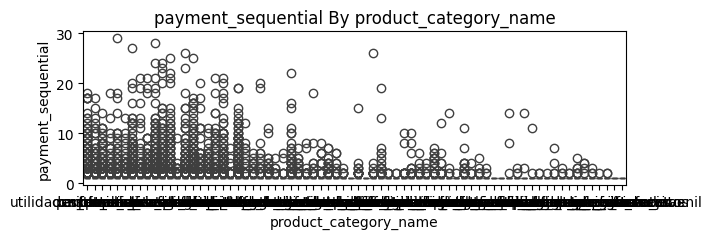


 Group Mean and Median of payment_sequential by product_category_name:
                               mean  median  count
product_category_name                             
Unknown                    1.708437     1.0   2809
agro_industria_e_comercio  5.216312     4.0   1128
alimentos                  1.151358     1.0    773
alimentos_bebidas          1.063265     1.0    490
artes                      1.111111     1.0    288
...                             ...     ...    ...
sinalizacao_e_seguranca    1.021226     1.0    424
tablets_impressao_imagem   1.120370     1.0    108
telefonia                  1.162641     1.0   6542
telefonia_fixa             1.036217     1.0    497
utilidades_domesticas      2.218382     1.0  14699

[72 rows x 3 columns]


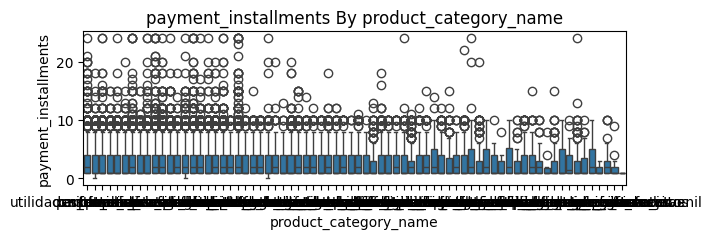


 Group Mean and Median of payment_installments by product_category_name:
                               mean  median  count
product_category_name                             
Unknown                    2.280527     1.0   2809
agro_industria_e_comercio  1.817376     1.0   1128
alimentos                  2.214748     1.0    773
alimentos_bebidas          1.989796     1.0    490
artes                      2.947917     1.0    288
...                             ...     ...    ...
sinalizacao_e_seguranca    3.099057     1.0    424
tablets_impressao_imagem   3.268519     2.0    108
telefonia                  2.491593     1.0   6542
telefonia_fixa             2.050302     1.0    497
utilidades_domesticas      2.733723     1.0  14699

[72 rows x 3 columns]


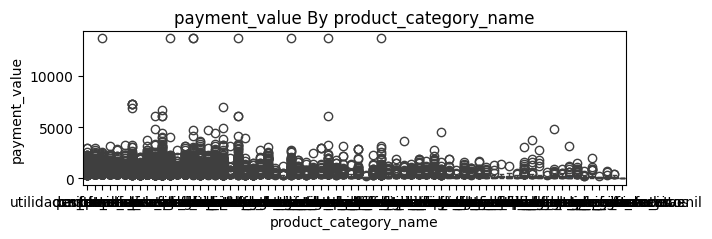


 Group Mean and Median of payment_value by product_category_name:
                                  mean   median  count
product_category_name                                 
Unknown                     164.973161   98.800   2809
agro_industria_e_comercio   328.483661   41.030   1128
alimentos                   100.605006   86.050    773
alimentos_bebidas           113.917735  100.690    490
artes                       156.208090  112.020    288
...                                ...      ...    ...
sinalizacao_e_seguranca     657.085024  132.305    424
tablets_impressao_imagem    118.545648  110.300    108
telefonia                   148.775376   52.920   6542
telefonia_fixa             2349.626740  324.150    497
utilidades_domesticas       177.705415   96.680  14699

[72 rows x 3 columns]


<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

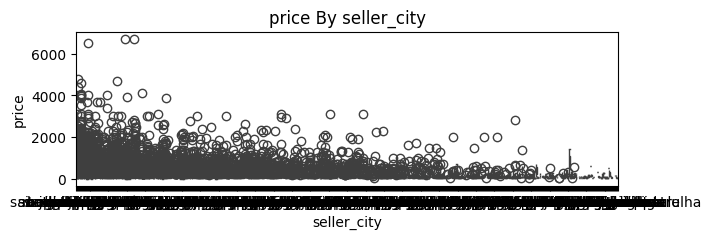


 Group Mean and Median of price by seller_city:
                       mean  median  count
seller_city                               
04482255         399.900000  399.90      1
abadia de goias  142.470000  142.47      1
afonso claudio    41.473750   18.90      8
aguas claras df   35.000000   35.00      1
alambari          27.720000   29.90      5
...                     ...     ...    ...
volta redonda     77.173673   55.90    226
votorantim        69.063080   68.90    578
votuporanga      143.230730  141.95    178
xanxere          267.459091  215.00     11
xaxim            222.000000  250.00      5

[572 rows x 3 columns]


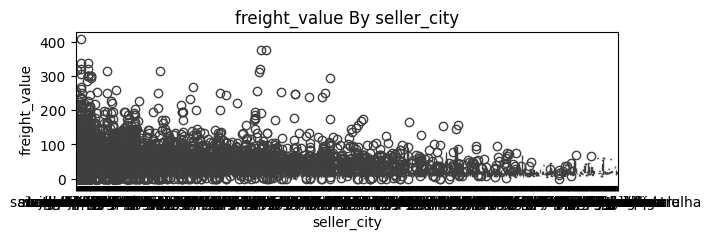


 Group Mean and Median of freight_value by seller_city:
                      mean  median  count
seller_city                              
04482255         16.550000   16.55      1
abadia de goias  43.410000   43.41      1
afonso claudio   19.206250   17.19      8
aguas claras df  17.780000   17.78      1
alambari         16.230000   16.11      5
...                    ...     ...    ...
volta redonda    19.458407   16.31    226
votorantim       17.644602   16.24    578
votuporanga      22.995843   18.29    178
xanxere          22.513636   17.95     11
xaxim            29.524000   32.40      5

[572 rows x 3 columns]


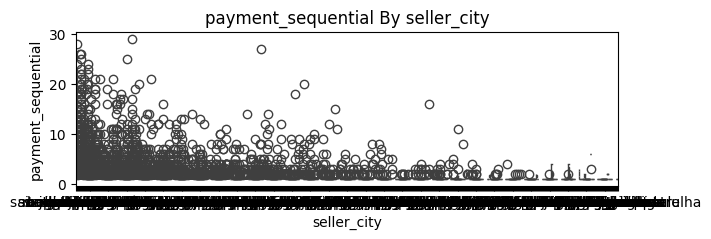


 Group Mean and Median of payment_sequential by seller_city:
                     mean  median  count
seller_city                             
04482255         1.000000     1.0      1
abadia de goias  1.000000     1.0      1
afonso claudio   1.000000     1.0      8
aguas claras df  1.000000     1.0      1
alambari         1.000000     1.0      5
...                   ...     ...    ...
volta redonda    1.212389     1.0    226
votorantim       2.069204     1.0    578
votuporanga      1.101124     1.0    178
xanxere          1.181818     1.0     11
xaxim            1.400000     1.0      5

[572 rows x 3 columns]


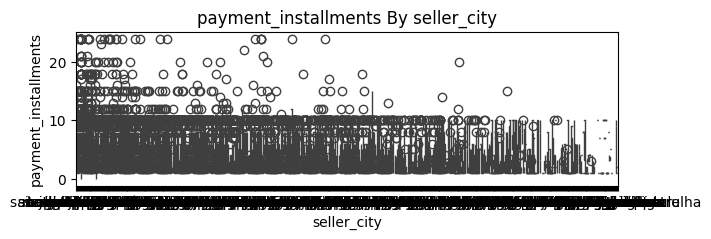


 Group Mean and Median of payment_installments by seller_city:
                     mean  median  count
seller_city                             
04482255         8.000000     8.0      1
abadia de goias  6.000000     6.0      1
afonso claudio   5.000000     6.0      8
aguas claras df  5.000000     5.0      1
alambari         1.600000     1.0      5
...                   ...     ...    ...
volta redonda    2.464602     1.0    226
votorantim       3.122837     1.0    578
votuporanga      3.651685     2.0    178
xanxere          4.818182     4.0     11
xaxim            2.000000     2.0      5

[572 rows x 3 columns]


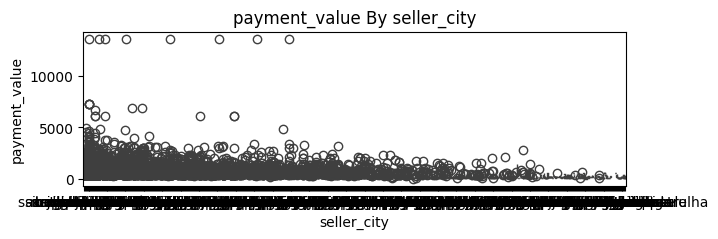


 Group Mean and Median of payment_value by seller_city:
                       mean  median  count
seller_city                               
04482255         416.450000  416.45      1
abadia de goias  185.880000  185.88      1
afonso claudio    78.725000   72.18      8
aguas claras df   52.780000   52.78      1
alambari          43.950000   46.01      5
...                     ...     ...    ...
volta redonda    116.692655   93.70    226
votorantim       163.849810   92.20    578
votuporanga      177.200169  173.23    178
xanxere          247.618182  232.95     11
xaxim            138.564000  128.02      5

[572 rows x 3 columns]


<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

<Figure size 700x200 with 0 Axes>

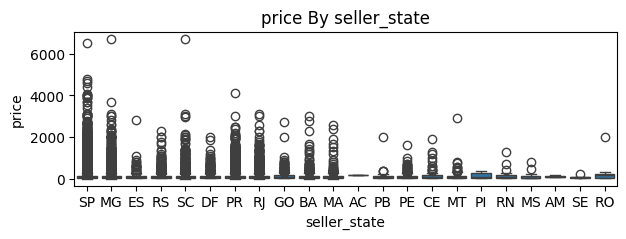


 Group Mean and Median of price by seller_state:
                    mean  median   count
seller_state                            
AC            267.000000  267.00       1
AM            392.333333  114.00       3
BA            452.435311  215.56    1207
CE            149.540397   64.90     151
DF            143.517039   79.00    1469
ES            112.870356   99.00     618
GO            133.952329  104.90     893
MA             88.256689   66.99     450
MG            111.857195   89.90   15187
MS            180.918800  184.90     175
MT            114.504353  120.00     170
PB            207.080857   54.90     105
PE            210.366672  149.90     655
PI            207.838462  285.00      13
PR            158.884704   99.00   15132
RJ            116.934444   74.99   10145
RN            178.619403   84.90      67
RO            320.806667  149.99      15
RS            165.320096   94.00    3246
SC            115.944849   64.90    8078
SE            148.150000  144.40      14
SP     

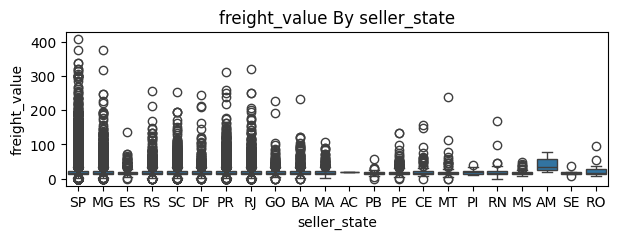


 Group Mean and Median of freight_value by seller_state:
                   mean  median   count
seller_state                           
AC            32.840000  32.840       1
AM            27.266667  25.290       3
BA            31.642925  27.380    1207
CE            36.626093  25.250     151
DF            30.249735  18.310    1469
ES            29.881278  23.800     618
GO            24.567234  22.180     893
MA            29.558000  27.510     450
MG            24.614368  18.230   15187
MS            25.211714  25.490     175
MT            31.507118  28.075     170
PB            26.824190  18.430     105
PE            26.884947  23.370     655
PI            37.123077  35.760      13
PR            24.299353  18.000   15132
RJ            18.200371  16.830   10145
RN            22.432090  18.270      67
RO            49.411333  52.710      15
RS            25.358527  19.620    3246
SC            22.952820  18.520    8078
SE            28.003571  26.360      14
SP            18.40450

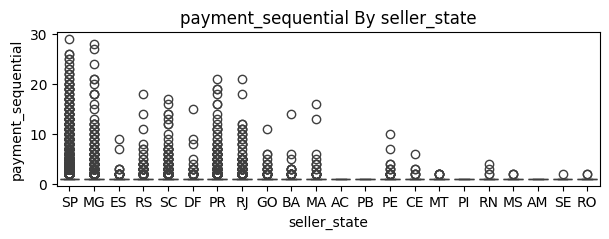


 Group Mean and Median of payment_sequential by seller_state:
                  mean  median   count
seller_state                          
AC            1.000000     1.0       1
AM            1.000000     1.0       3
BA            1.550953     1.0    1207
CE            1.649007     1.0     151
DF            1.962560     1.0    1469
ES            1.318770     1.0     618
GO            1.278835     1.0     893
MA            1.017778     1.0     450
MG            1.673734     1.0   15187
MS            4.457143     4.0     175
MT            1.023529     1.0     170
PB            1.914286     1.0     105
PE            1.094656     1.0     655
PI            1.000000     1.0      13
PR            2.277326     1.0   15123
RJ            3.704189     1.0   10145
RN            1.000000     1.0      67
RO            1.000000     1.0      15
RS            1.105669     1.0    3246
SC            2.782619     1.0    8078
SE            1.000000     1.0      14
SP            1.519746     1.0  135676


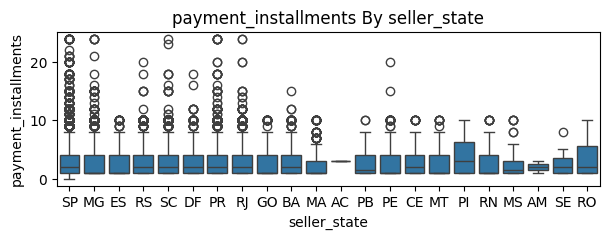


 Group Mean and Median of payment_installments by seller_state:
                  mean  median   count
seller_state                          
AC            1.000000     1.0       1
AM            3.666667     1.0       3
BA            4.041425     3.0    1207
CE            2.423841     1.0     151
DF            2.744724     1.0    1469
ES            3.127832     1.0     618
GO            2.882419     1.0     893
MA            2.948889     3.0     450
MG            2.868572     1.0   15187
MS            2.000000     1.0     175
MT            3.647059     2.5     170
PB            2.619048     1.0     105
PE            2.703817     1.0     655
PI            6.769231     6.0      13
PR            2.854328     1.0   15123
RJ            2.418137     1.0   10145
RN            3.283582     3.0      67
RO            6.333333     5.0      15
RS            3.285274     2.0    3246
SC            3.039985     1.0    8078
SE            7.214286    10.0      14
SP            2.862717     1.0  135676

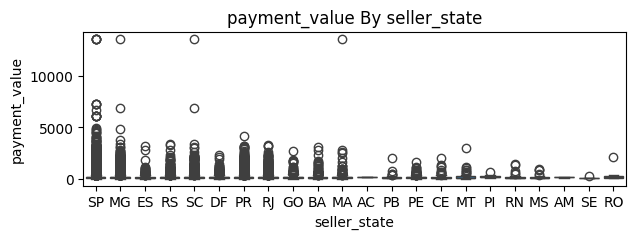


 Group Mean and Median of payment_value by seller_state:
                    mean   median   count
seller_state                             
AC            299.840000  299.840       1
AM            419.600000  139.290       3
BA            536.502759  307.460    1207
CE            190.884768  120.330     151
DF            150.697495   92.190    1469
ES            222.060113  148.300     618
GO            324.167794  129.220     893
MA            136.624689  131.820     450
MG            203.529923  111.430   15187
MS             85.088800   20.450     175
MT            164.189882  160.220     170
PB            253.873429   81.930     105
PE            327.464641  186.270     655
PI            287.535385  319.940      13
PR            218.917951  131.260   15123
RJ            182.960177  100.000   10145
RN            276.854478  112.340      67
RO            386.456000  243.570      15
RS            340.876389  157.940    3246
SC            199.183948  114.850    8078
SE            265.

In [30]:
for cat_col in df:
    for num_col in num_df:
        plt.figure(figsize=(7, 2))
        if 'id' in cat_col.lower() or 'id'in num_col.lower():
            continue
        sns.boxplot(x = df[cat_col], y = num_df[num_col])
        plt.title(f'{num_col} By {cat_col}')
        plt.show()

        print(f"\n Group Mean and Median of {num_col} by {cat_col}:")
        print(full_df.groupby(cat_col)[num_col].agg(['mean', 'median', 'count']))

### Annova Test

### Price vs Product Category

In [31]:
from scipy import stats
annova_res = stats.f_oneway(*[group['price'].values for name, group in full_df.groupby('product_category_name')])
print("ANOVA Test for Price across Product Categories:")
print("F-Statistics:", round(annova_res.statistic, 3), ", p-value:", round(annova_res.pvalue, 3))

ANOVA Test for Price across Product Categories:
F-Statistics: 396.056 , p-value: 0.0


### Freight Value vs Product Category

In [32]:

annova_res = stats.f_oneway(*[group['freight_value'].values for name, group in full_df.groupby('product_category_name')])
print("ANOVA Test for Freight Value across Product Categories:")
print("F-Statistics:", round(annova_res.statistic, 3), ", p-value:", round(annova_res.pvalue, 3))

ANOVA Test for Freight Value across Product Categories:
F-Statistics: 247.267 , p-value: 0.0


### Payment Value vs Payment Type

In [35]:
annova_df = full_df[['payment_type', 'payment_value']].dropna()
annova_res = stats.f_oneway(*[group['payment_value'].values for name, group in annova_df.groupby('payment_type')])
print("ANOVA Test for Payment Value across Payment Type:")
print("F-Statistics:", round(annova_res.statistic, 3), ", p-value:", round(annova_res.pvalue, 3))

ANOVA Test for Payment Value across Payment Type:
F-Statistics: 2531.702 , p-value: 0.0


### Payment Installments vs Payment Type

In [34]:
annova_df = full_df[['payment_type', 'payment_installments']].dropna()
annova_res = stats.f_oneway(*[group['payment_installments'].values for name, group in annova_df.groupby('payment_type')])
print("ANOVA Test for Payment Installments across Payment Type:")
print("F-Statistics:", round(annova_res.statistic, 3), ", p-value:", round(annova_res.pvalue, 3))

ANOVA Test for Payment Installments across Payment Type:
F-Statistics: 17116.823 , p-value: 0.0


In [45]:
full_df
#num_df

,order_id,customer_id,order_status,customer_city,customer_state,payment_type,product_id_x,seller_id_x,product_category_name,seller_city,seller_state,product_id_y,seller_id_y,price,freight_value,payment_sequential,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,sao paulo,SP,credit_card,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,maua,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,1.0,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,sao paulo,SP,credit_card,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,maua,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,3.0,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,sao paulo,SP,credit_card,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,maua,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2.0,1.0,18.59
3,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,sao paulo,SP,voucher,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,maua,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,1.0,1.0,18.12
4,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,sao paulo,SP,voucher,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,maua,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,3.0,1.0,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194295,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,japuiba,RJ,credit_card,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,informatica_acessorios,ilicinea,MG,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99,40.59,1.0,4.0,441.16
194296,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,japuiba,RJ,credit_card,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,informatica_acessorios,ilicinea,MG,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99,40.59,1.0,4.0,441.16
194297,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,japuiba,RJ,credit_card,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,informatica_acessorios,ilicinea,MG,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99,40.59,1.0,4.0,441.16
194298,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,japuiba,RJ,credit_card,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,informatica_acessorios,ilicinea,MG,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99,40.59,1.0,4.0,441.16


#### Category - Category

#### Chic Square Test

#### Payment Type vs Order Status


Contigency Table (Payment Type vs Order Status):
 order_status  approved  canceled  created  delivered  invoiced  processing  \
payment_type                                                                 
boleto               0       186        2      33606       186         199   
credit_card          5       782        3     122076       333         355   
debit_card           0         7        0       2179         6           2   
not_defined          0         3        0          0         0           0   
voucher              0       197        0      31002        34         125   

order_status  shipped  unavailable  
payment_type                        
boleto            254          150  
credit_card      1121          449  
debit_card         25            6  
not_defined         0            0  
voucher           951           47  


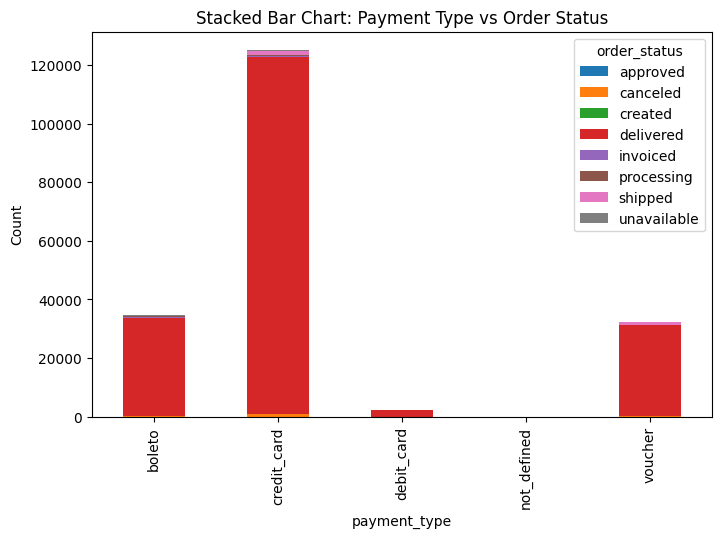


Chi-Square Test Result:
chic2 = 1712.399, p-value = 0.000, Degree of Freedom = 28
Significant relationship (reject null hypothesis)


In [44]:
from scipy.stats import chi2_contingency

contigency = pd.crosstab(full_df['payment_type'], full_df['order_status'])
print('\nContigency Table (Payment Type vs Order Status):\n',contigency)

contigency.plot(kind = 'bar', stacked = True, figsize=(8, 5))
plt.title('Stacked Bar Chart: Payment Type vs Order Status')
plt.ylabel('Count')
plt.show()

chic2, p, dof, expected = chi2_contingency(contigency)
print('\nChi-Square Test Result:')
print(f'chic2 = {chic2:.3f}, p-value = {p:.3f}, Degree of Freedom = {dof}')

if p < 0.05:
    print("Significant relationship (reject null hypothesis)")
else:
    print("No Significant relationship (fail to reject null hypothesis)")

### Product Category Name × Order Status

In [49]:
contigency = pd.crosstab(full_df['product_category_name'], full_df['order_status'])
print('\nContigency Table (Product Category Name vs Order Status):\n',contigency)

# contigency.plot(kind = 'bar', stacked = True, figsize=(8, 8))
# plt.title('Stacked Bar Chart: Product Category Name vs Order Status')
# plt.ylabel('Count')
# plt.show()

chic2, p, dof, expected = chi2_contingency(contigency)
print('\nChi-Square Test Result:')
print(f'chic2 = {chic2:.3f}, p-value = {p:.3f}, Degree of Freedom = {dof}')

if p < 0.05:
    print("Significant relationship (reject null hypothesis)")
else:
    print("No Significant relationship (fail to reject null hypothesis)")


Contigency Table (Product Category Name vs Order Status):
 order_status               approved  canceled  delivered  invoiced  \
product_category_name                                                
Unknown                           0        17       2695        33   
agro_industria_e_comercio         0         0       1120         1   
alimentos                         0         1        756         0   
alimentos_bebidas                 0         2        466        16   
artes                             0         1        246         0   
...                             ...       ...        ...       ...   
sinalizacao_e_seguranca           0         0        422         0   
tablets_impressao_imagem          0         0        108         0   
telefonia                         0        25       6394        33   
telefonia_fixa                    0         6        465         0   
utilidades_domesticas             1       185      14330        37   

order_status               pr

### Customer State × Order Status

In [50]:
contigency = pd.crosstab(full_df['customer_state'], full_df['order_status'])
print('\nContigency Table (Customer State vs Order Status):\n',contigency)

chic2, p, dof, expected = chi2_contingency(contigency)
print('\nChi-Square Test Result:')
print(f'chic2 = {chic2:.3f}, p-value = {p:.3f}, Degree of Freedom = {dof}')

if p < 0.05:
    print("Significant relationship (reject null hypothesis)")
else:
    print("No Significant relationship (fail to reject null hypothesis)")


Contigency Table (Customer State vs Order Status):
 order_status    approved  canceled  created  delivered  invoiced  processing  \
customer_state                                                                 
AC                     0         0        0        146         0           0   
AL                     0         1        0        559         2          18   
AM                     0         0        0        247         0           0   
AP                     0         0        0        129         0           1   
BA                     0        19        0       6238         9          46   
CE                     0         7        0       2295         1           8   
DF                     0        31        1       3409         3          10   
ES                     0        12        0       3225         4           2   
GO                     0        19        0       4340         5          13   
MA                     0         4        0       1118         2   

### Seller State × Order Status

In [51]:
contigency = pd.crosstab(full_df['seller_state'], full_df['order_status'])
print('\nContigency Table (Seller State vs Order Status):\n',contigency)

chic2, p, dof, expected = chi2_contingency(contigency)
print('\nChi-Square Test Result:')
print(f'chic2 = {chic2:.3f}, p-value = {p:.3f}, Degree of Freedom = {dof}')

if p < 0.05:
    print("Significant relationship (reject null hypothesis)")
else:
    print("No Significant relationship (fail to reject null hypothesis)")


Contigency Table (Seller State vs Order Status):
 order_status  approved  canceled  delivered  invoiced  processing  shipped  \
seller_state                                                                 
AC                   0         0          0         0           1        0   
AM                   0         0          3         0           0        0   
BA                   0         2       1188         7           5        5   
CE                   0         0        147         0           0        3   
DF                   0         3       1450         5           1       10   
ES                   0         0        608         0           2        6   
GO                   0         6        878         0           2        7   
MA                   0         0        447         0           0        3   
MG                   4        73      14827        55          47      181   
MS                   0         0        175         0           0        0   
MT           

### ACF - Time Series Analysis

In [61]:
from statsmodels.graphics.tsaplots import plot_acf

daily_sales = orders.groupby(orders['order_purchase_timestamp'].dt.date).size()
daily_sales.index = pd.to_datetime(daily_sales.index)

daily_sales = daily_sales.sort_index()


<Figure size 640x480 with 0 Axes>

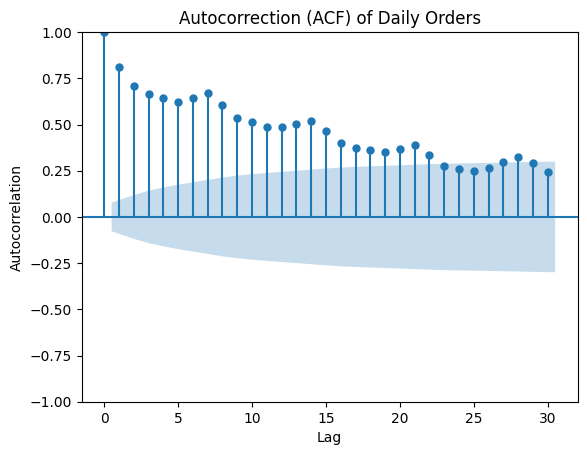

In [65]:
plt.figure()
plot_acf(daily_sales, lags=30)
plt.title("Autocorrection (ACF) of Daily Orders")
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

### PACF - Time Series Analysis

<Figure size 640x480 with 0 Axes>

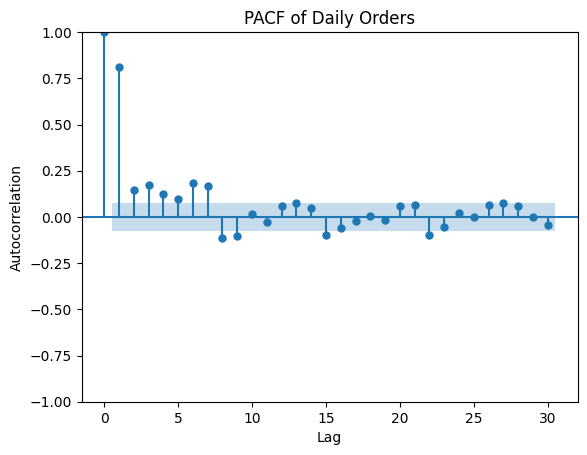

In [67]:
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure()
plot_pacf(daily_sales, lags=30)
plt.title("PACF of Daily Orders")
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

### Multivariate Analysis

                  price  freight_value
price          1.000000       0.394224
freight_value  0.394224       1.000000


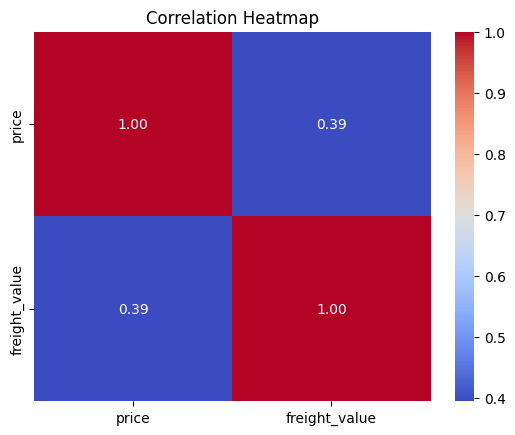

In [70]:
numeric_df = full_df[['price', 'freight_value']]
correlation = numeric_df.corr()
print(correlation)

sns.heatmap(correlation, annot=True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()

### Price vs Freight vs Product Category

In [72]:
result = full_df.groupby('product_category_name')[['price', 'freight_value']].mean()
display(result)

,price,freight_value
product_category_name,,
Unknown,104.020662,21.135568
agro_industria_e_comercio,321.948112,27.725869
alimentos,50.767503,13.859043
alimentos_bebidas,52.378143,15.811796
artes,96.247812,19.071910
...,...,...
sinalizacao_e_seguranca,115.002948,47.504623
tablets_impressao_imagem,90.504722,15.122222
telefonia,72.220625,15.569375


### Payment Type vs Installments vs Payment Value

In [73]:
result = full_df.groupby('payment_type')[['payment_value', 'payment_installments']].mean()
display(result)

,payment_value,payment_installments
payment_type,,
boleto,300.133991,1.000000
credit_card,234.034411,3.840844
debit_card,169.392579,1.000902
not_defined,NaN,NaN
voucher,41.438590,1.188561


### Customer State vs Product Category vs Price

In [75]:
result = full_df.groupby(['customer_state', 'product_category_name'])[['price']].mean()
display(result)

price
customer_state product_category_name                   
AC             Unknown                        33.450000
               artigos_de_natal               69.900000
               automotivo                    105.564286
               bebes                         232.613333
               beleza_saude                  195.153333
...                                                 ...
TO             portateis_casa_forno_e_cafe  1999.000000
               relogios_presentes            162.444474
               telefonia                      57.134783
               telefonia_fixa                695.495000
               utilidades_domesticas          63.181923

[1366 rows x 1 columns]

In [82]:
num_df1 = num_df[['price', 'freight_value', 'payment_sequential', 'payment_installments', 'payment_value']]
num_df1 = num_df1.dropna()

### PCA(Priniciple Component Analysis)

In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

scalar = StandardScaler()
x_scaled = scalar.fit_transform(num_df1)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

num_df1['PCA1'] = x_pca[:, 0]
num_df1['PCA2'] = x_pca[:, 1]

print('Explained Variance Ratio:', pca.explained_variance_ratio_)

Explained Variance Ratio: [0.45688632 0.29076981]


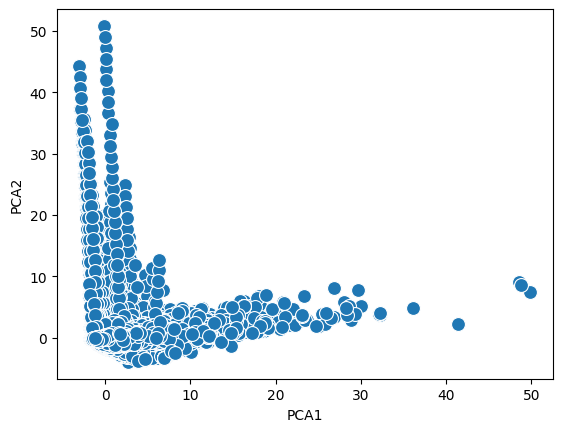

In [87]:
plt.figure()
sns.scatterplot(x = 'PCA1', y = 'PCA2', data = num_df1, s= 100)
plt.show()

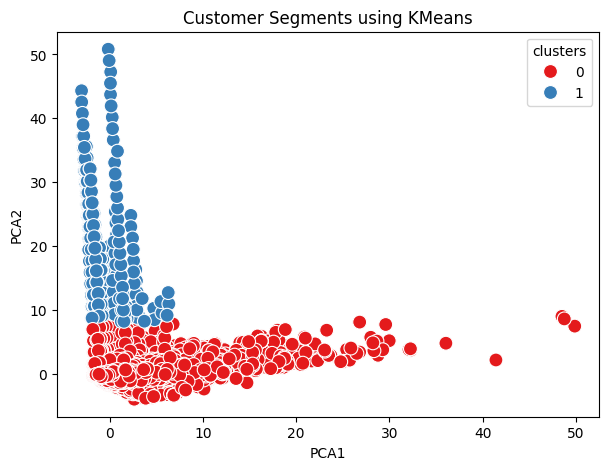

In [90]:
kmeans = KMeans(n_clusters=2, random_state=42)
num_df1['clusters'] = kmeans.fit_predict(x_pca)
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x = 'PCA1',
    y = 'PCA2',
    hue = 'clusters',
    data=num_df1,
    palette='Set1',
    s = 100
)
plt.title('Customer Segments using KMeans')
plt.show()
